# Multi-output rates with a mass-conservation penalty

This notebook compares four independent rate networks with one shared network that predicts `rNH3`, `rN2`, `rNO`, and `rN2O`. It also tests a soft nitrogen-atom balance penalty. All target rates remain signed and in their original units: no rate logs or target scaling are used. Feature scaling is computed from training rows only.

For the three stated global reactions, let their forward extents be `xi1`, `xi2`, `xi3`. Then `rNH3 = -4(xi1+xi2+xi3)`, `rNO = 4xi1`, `rN2 = 2xi2`, and `rN2O = 2xi3`, giving the balance `rNH3 + rNO + 2*rN2 + 2*rN2O = 0`.

Use validation performance to compare architectures and penalty strengths. The saved test evaluation was run before later architecture studies, so those results are no longer a pristine final holdout. Do not use them to choose a model; reserve fresh data for an unbiased final estimate.

In [29]:
import copy
import hashlib
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

ACTIVITY_DIR = Path.cwd()
if not (ACTIVITY_DIR / 'rates.csv').exists():
    for activity_folder in ('kinetics-dae-nn', 'NN_interpolation'):
        candidate_dir = ACTIVITY_DIR / activity_folder
        if (candidate_dir / 'rates.csv').exists():
            ACTIVITY_DIR = candidate_dir
            break
CSV_PATH = ACTIVITY_DIR / 'rates.csv'
TARGETS = ['rNH3', 'rN2', 'rNO', 'rN2O']
FEATURES = ['T', 'xNH3', 'xO2', 'xNO']
BALANCE_COEFFICIENTS = np.array([1.0, 2.0, 1.0, 2.0], dtype=np.float64)
SEED = 2026
WIDTH = 128
BATCH_SIZE = 512
MAX_EPOCHS = 250
PATIENCE = 30
LEARNING_RATE = 1e-3

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training device:', device)

Training device: cpu


In [30]:
data = pd.read_csv(CSV_PATH)[FEATURES + TARGETS].copy()
if len(data) < 20:
    raise ValueError('Need at least 20 rows to create train/validation/test splits')
if not np.isfinite(data.to_numpy(dtype=np.float64)).all():
    raise ValueError('Input data contains NaN or infinite values')
if (data['T'] <= 0).any():
    raise ValueError('Temperature must be strictly positive for 1/T')
if (data[['xNH3', 'xO2', 'xNO']] <= 0).any().any():
    raise ValueError('Concentrations must be strictly positive for log transforms')

train_val_idx, test_idx = train_test_split(
    np.arange(len(data)), test_size=0.15, random_state=SEED, shuffle=True
)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.15 / 0.85, random_state=SEED, shuffle=True
)
train_df = data.iloc[train_idx].copy()
val_df = data.iloc[val_idx].copy()
test_df = data.iloc[test_idx].copy()
print(f'Rows: train={len(train_df)}, validation={len(val_df)}, test={len(test_df)}')

def kinetic_features(frame):
    return np.column_stack([
        1.0 / frame['T'].to_numpy(dtype=np.float64),
        np.log(frame['xNH3'].to_numpy(dtype=np.float64)),
        np.log(frame['xO2'].to_numpy(dtype=np.float64)),
        np.log(frame['xNO'].to_numpy(dtype=np.float64)),
    ])

x_train_raw = kinetic_features(train_df)
x_val_raw = kinetic_features(val_df)
x_test_raw = kinetic_features(test_df)
x_mean = x_train_raw.mean(axis=0)
x_std = x_train_raw.std(axis=0)
if not np.isfinite(x_std).all() or np.any(x_std == 0):
    raise ValueError('At least one transformed input has zero or invalid training variance')
x_train = (x_train_raw - x_mean) / x_std
x_val = (x_val_raw - x_mean) / x_std
x_test = (x_test_raw - x_mean) / x_std

# Targets are left in original units and are never logged or standardized.
y_train = train_df[TARGETS].to_numpy(dtype=np.float64)
y_val = val_df[TARGETS].to_numpy(dtype=np.float64)
y_test = test_df[TARGETS].to_numpy(dtype=np.float64)
target_scales = y_train.std(axis=0)
if not np.isfinite(target_scales).all() or np.any(target_scales == 0):
    raise ValueError('At least one training rate has zero or invalid variance')

data_fingerprint = hashlib.sha256()
for fingerprint_array in (x_train, y_train, x_val, y_val, target_scales):
    data_fingerprint.update(repr((fingerprint_array.shape, fingerprint_array.dtype.str)).encode('utf-8'))
    data_fingerprint.update(np.ascontiguousarray(fingerprint_array).tobytes())
DATA_FINGERPRINT = data_fingerprint.hexdigest()

# Only nondimensionalizes the objective weights; network targets/predictions remain raw.
balance_scale = float(np.linalg.norm(BALANCE_COEFFICIENTS * target_scales))
if not np.isfinite(balance_scale) or balance_scale <= 0:
    raise ValueError('Cannot determine a finite mass-balance penalty scale')

def conservation_residual(rates):
    return rates @ BALANCE_COEFFICIENTS

for split_name, split_y in [('train', y_train), ('validation', y_val), ('test', y_test)]:
    residual = conservation_residual(split_y)
    print(f'{split_name} observed balance RMSE: {np.sqrt(np.mean(residual ** 2)):.6g}')
print('Rate columns:', TARGETS)
print('Training standard deviations used only for loss weighting:', dict(zip(TARGETS, target_scales)))
print('Mass-balance residual scale:', balance_scale)

Rows: train=69999, validation=15001, test=15000
train observed balance RMSE: 1.51088e-06
validation observed balance RMSE: 1.29147e-06
test observed balance RMSE: 2.84697e-06
Rate columns: ['rNH3', 'rN2', 'rNO', 'rN2O']
Training standard deviations used only for loss weighting: {'rNH3': np.float64(10.266847932116702), 'rN2': np.float64(3.4406130933141426), 'rNO': np.float64(5.88677225542683), 'rN2O': np.float64(4.749570450514439)}
Mass-balance residual scale: 16.662749045028875


In [31]:
class RateNetwork(nn.Module):
    def __init__(self, output_dim, hidden_dims=None, activation='relu', enforce_balance=False):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = (WIDTH, WIDTH)
        activation_layers = {
            'relu': nn.ReLU,
            'gelu': nn.GELU,
            'silu': nn.SiLU,
            'tanh': nn.Tanh,
        }
        if activation not in activation_layers:
            raise ValueError(f'Unsupported activation {activation!r}; choose from {tuple(activation_layers)}')
        if enforce_balance and output_dim != len(TARGETS):
            raise ValueError('Exact balance enforcement requires one output for each target rate')
        self.enforce_balance = enforce_balance
        self.register_buffer(
            'balance_coefficients',
            torch.as_tensor(BALANCE_COEFFICIENTS, dtype=torch.float64),
        )
        self.register_buffer(
            'projection_variances',
            torch.as_tensor(np.square(target_scales), dtype=torch.float64),
        )
        layers = []
        input_dim = len(FEATURES)
        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(input_dim, hidden_dim), activation_layers[activation]()])
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, output_dim))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        prediction = self.layers(x)
        if self.enforce_balance:
            prediction = prediction.to(dtype=torch.float64)
            coefficients = self.balance_coefficients
            variances = self.projection_variances
            denominator = torch.sum(coefficients.square() * variances)
            residual = prediction @ coefficients
            prediction = prediction - (residual / denominator).unsqueeze(1) * variances * coefficients
        return prediction

x_train_t = torch.tensor(x_train, dtype=torch.float32, device=device)
x_val_t = torch.tensor(x_val, dtype=torch.float32, device=device)
x_test_t = torch.tensor(x_test, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.float32, device=device)
target_scales_t = torch.tensor(target_scales, dtype=torch.float32, device=device)
balance_coefficients_t = torch.tensor(BALANCE_COEFFICIENTS, dtype=torch.float32, device=device)
balance_scale_t = torch.tensor(balance_scale, dtype=torch.float32, device=device)

def score_rates(truth, prediction):
    error = prediction - truth
    rmse = np.sqrt(np.mean(error ** 2, axis=0))
    mae = np.mean(np.abs(error), axis=0)
    observed_balance = conservation_residual(truth)
    predicted_balance = conservation_residual(prediction)
    return {
        'rmse': dict(zip(TARGETS, rmse.tolist())),
        'mae': dict(zip(TARGETS, mae.tolist())),
        'balance_rmse': float(np.sqrt(np.mean(predicted_balance ** 2))),
        'observed_balance_rmse': float(np.sqrt(np.mean(observed_balance ** 2))),
    }

def score_validation_errors(truth, prediction):
    error = prediction - truth
    centered_truth = truth - truth.mean(axis=0)
    total_sum_squares = np.sum(centered_truth ** 2, axis=0)
    residual_sum_squares = np.sum(error ** 2, axis=0)
    r2 = np.full(len(TARGETS), np.nan, dtype=np.float64)
    np.divide(
        residual_sum_squares,
        total_sum_squares,
        out=r2,
        where=total_sum_squares > 0,
    )
    r2 = np.where(total_sum_squares > 0, 1.0 - r2, np.nan)
    return {
        'r2': dict(zip(TARGETS, r2.tolist())),
        'min_error': dict(zip(TARGETS, error.min(axis=0).tolist())),
        'max_error': dict(zip(TARGETS, error.max(axis=0).tolist())),
        'max_abs_error': dict(zip(TARGETS, np.abs(error).max(axis=0).tolist())),
    }

def validation_objective(model, loader, penalty_weight, enforce_balance=False):
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb)
            data_loss = (((pred - yb) / target_scales_t) ** 2).mean()
            if enforce_balance:
                objective = data_loss
            else:
                balance_loss = ((pred @ balance_coefficients_t) / balance_scale_t).square().mean()
                objective = data_loss + penalty_weight * balance_loss
            total += objective.item() * len(xb)
            count += len(xb)
    return total / count

def train_shared_model(name, penalty_weight=0.0, hidden_dims=None, learning_rate=None, weight_decay=1e-5, activation='relu', enforce_balance=False):
    requested_hidden_dims = list(hidden_dims or (WIDTH, WIDTH))
    requested_learning_rate = LEARNING_RATE if learning_rate is None else learning_rate
    if enforce_balance and penalty_weight != 0.0:
        raise ValueError('Set penalty_weight=0 when enforce_balance=True; conservation is then an exact constraint, not a soft penalty.')
    if name in SHARED_MODELS and name in SHARED_RESULTS:
        cached_metrics = SHARED_RESULTS[name]
        cached_config = (
            cached_metrics.get('penalty_weight'),
            cached_metrics.get('hidden_dims', [WIDTH, WIDTH]),
            cached_metrics.get('learning_rate', LEARNING_RATE),
            cached_metrics.get('weight_decay', 1e-5),
            cached_metrics.get('activation', 'relu'),
            cached_metrics.get('enforce_balance', False),
        )
        requested_config = (penalty_weight, requested_hidden_dims, requested_learning_rate, weight_decay, activation, enforce_balance)
        if cached_config != requested_config:
            raise ValueError(
                f'{name!r} is already cached with configuration {cached_config}; '
                f'requested {requested_config}. Use a new model name to train a different configuration.'
            )
        print(f'{name}: reusing cached model and validation results')
        return SHARED_MODELS[name]
    torch.manual_seed(SEED)
    model = RateNetwork(
        output_dim=len(TARGETS),
        hidden_dims=hidden_dims,
        activation=activation,
        enforce_balance=enforce_balance,
    ).to(device)
    learning_rate = requested_learning_rate
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    train_ds = TensorDataset(x_train_t, y_train_t)
    val_ds = TensorDataset(x_val_t, y_val_t)
    loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    best_val, best_state, best_epoch, wait = float('inf'), None, 0, 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            data_loss = (((pred - yb) / target_scales_t) ** 2).mean()
            if enforce_balance:
                loss = data_loss
            else:
                balance_loss = ((pred @ balance_coefficients_t) / balance_scale_t).square().mean()
                loss = data_loss + penalty_weight * balance_loss
            if not torch.isfinite(loss):
                raise FloatingPointError(f'{name}: non-finite training loss at epoch {epoch + 1}')
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        val_obj = validation_objective(model, val_loader, penalty_weight, enforce_balance)
        if not np.isfinite(val_obj):
            raise FloatingPointError(f'{name}: non-finite validation objective at epoch {epoch + 1}')
        if val_obj < best_val - 1e-8:
            best_val = val_obj
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, wait = epoch + 1, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    if best_state is None:
        raise RuntimeError(f'{name}: training produced no valid checkpoint')
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_pred = model(x_val_t).cpu().numpy()
    metrics = score_rates(y_val, val_pred)
    metrics.update(score_validation_errors(y_val, val_pred))
    metrics['penalty_weight'] = penalty_weight
    metrics['hidden_dims'] = list(hidden_dims or (WIDTH, WIDTH))
    metrics['parameter_count'] = sum(parameter.numel() for parameter in model.parameters())
    metrics['learning_rate'] = learning_rate
    metrics['weight_decay'] = weight_decay
    metrics['activation'] = activation
    metrics['enforce_balance'] = enforce_balance
    metrics['best_epoch'] = best_epoch
    metrics['val_objective'] = best_val
    SHARED_MODELS[name] = model
    SHARED_RESULTS[name] = metrics
    SHARED_VALIDATION_PREDICTIONS[name] = val_pred.copy()
    save_model_checkpoint(
        kind='shared',
        name=name,
        model_states=model.state_dict(),
        metrics=metrics,
        validation_prediction=val_pred,
        config={
            'hidden_dims': metrics['hidden_dims'],
            'activation': activation,
            'enforce_balance': enforce_balance,
        },
    )
    print(name, metrics)
    return model

def train_separate_models(name='separate-networks'):
    if name in SEPARATE_MODELS and name in SEPARATE_RESULTS:
        print(f'{name}: reusing cached model and validation results')
        return SEPARATE_MODELS[name]
    models = []
    for target_index, target_name in enumerate(TARGETS):
        torch.manual_seed(SEED)
        model = RateNetwork(output_dim=1).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
        train_ds = TensorDataset(x_train_t, y_train_t[:, target_index:target_index + 1])
        val_ds = TensorDataset(x_val_t, y_val_t[:, target_index:target_index + 1])
        loader = DataLoader(
            train_ds, batch_size=BATCH_SIZE, shuffle=True,
            generator=torch.Generator().manual_seed(SEED),
        )
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
        best_val, best_state, best_epoch, wait = float('inf'), None, 0, 0
        scale = target_scales_t[target_index]

        for epoch in range(MAX_EPOCHS):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad(set_to_none=True)
                pred = model(xb)
                loss = (((pred - yb) / scale) ** 2).mean()
                if not torch.isfinite(loss):
                    raise FloatingPointError(f'{target_name}: non-finite training loss at epoch {epoch + 1}')
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            model.eval()
            val_sum, val_count = 0.0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    val_sum += (((model(xb) - yb) / scale) ** 2).sum().item()
                    val_count += len(xb)
            val_loss = val_sum / val_count
            if val_loss < best_val - 1e-8:
                best_val = val_loss
                best_state = copy.deepcopy(model.state_dict())
                best_epoch, wait = epoch + 1, 0
            else:
                wait += 1
                if wait >= PATIENCE:
                    break

        if best_state is None:
            raise RuntimeError(f'{target_name}: training produced no valid checkpoint')
        model.load_state_dict(best_state)
        models.append(model)
        print(f'{target_name}: best epoch {best_epoch}, validation normalized MSE {best_val:.6g}')

    with torch.no_grad():
        val_pred = np.column_stack([m(x_val_t).squeeze(1).cpu().numpy() for m in models])
    metrics = score_rates(y_val, val_pred)
    metrics.update(score_validation_errors(y_val, val_pred))
    metrics['penalty_weight'] = None
    SEPARATE_MODELS[name] = models
    SEPARATE_RESULTS[name] = metrics
    save_model_checkpoint(
        kind='separate',
        name=name,
        model_states=[model.state_dict() for model in models],
        metrics=metrics,
        validation_prediction=val_pred,
        config={'hidden_dims': [WIDTH, WIDTH], 'activation': 'relu'},
    )
    print(name, metrics)
    return models

if 'SHARED_MODELS' not in globals():
    SHARED_MODELS = {}
if 'SHARED_RESULTS' not in globals():
    SHARED_RESULTS = {}
if 'SHARED_VALIDATION_PREDICTIONS' not in globals():
    SHARED_VALIDATION_PREDICTIONS = {}
if 'SEPARATE_MODELS' not in globals():
    SEPARATE_MODELS = {}
if 'SEPARATE_RESULTS' not in globals():
    SEPARATE_RESULTS = {}

CHECKPOINT_DIR = ACTIVITY_DIR / 'model_checkpoints'
CHECKPOINT_FORMAT_VERSION = 1

def _checkpoint_safe_value(value):
    if isinstance(value, dict):
        return {str(key): _checkpoint_safe_value(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_checkpoint_safe_value(item) for item in value]
    if isinstance(value, np.ndarray):
        return _checkpoint_safe_value(value.tolist())
    if isinstance(value, np.generic):
        return value.item()
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    raise TypeError(f'Unsupported value in checkpoint metadata: {type(value).__name__}')

def save_model_checkpoint(kind, name, model_states, metrics, validation_prediction, config):
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    safe_name = hashlib.sha256(f'{kind}:{name}'.encode('utf-8')).hexdigest()[:16]
    path = CHECKPOINT_DIR / f'{kind}-{safe_name}.pt'
    state_list = model_states if isinstance(model_states, (list, tuple)) else [model_states]
    payload = {
        'format_version': CHECKPOINT_FORMAT_VERSION,
        'data_fingerprint': DATA_FINGERPRINT,
        'kind': kind,
        'name': name,
        'config': _checkpoint_safe_value(config),
        'metrics': _checkpoint_safe_value(metrics),
        'model_states': [
            {key: tensor.detach().cpu() for key, tensor in state.items()}
            for state in state_list
        ],
        'validation_prediction': torch.as_tensor(validation_prediction).cpu(),
    }
    temporary_path = path.with_suffix('.pt.tmp')
    try:
        torch.save(payload, temporary_path)
        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()
    print(f'Saved {kind} model {name!r} to {path}')

def load_model_checkpoints():
    if not CHECKPOINT_DIR.exists():
        print(f'No saved model checkpoints found at {CHECKPOINT_DIR}.')
        return
    restored = 0
    skipped = 0
    for path in sorted(CHECKPOINT_DIR.glob('*.pt')):
        payload = torch.load(path, map_location='cpu', weights_only=True)
        if payload.get('format_version') != CHECKPOINT_FORMAT_VERSION:
            print(f'Skipping checkpoint with unsupported format version: {path}')
            skipped += 1
            continue
        if payload.get('data_fingerprint') != DATA_FINGERPRINT:
            print(f'Skipping checkpoint for different train/validation data: {path}')
            skipped += 1
            continue
        kind = payload['kind']
        name = payload['name']
        if kind == 'shared' and name in SHARED_MODELS and name in SHARED_RESULTS:
            continue
        if kind == 'separate' and name in SEPARATE_MODELS and name in SEPARATE_RESULTS:
            continue
        config = payload['config']
        states = payload['model_states']
        if kind == 'shared':
            model = RateNetwork(
                output_dim=len(TARGETS),
                hidden_dims=config['hidden_dims'],
                activation=config['activation'],
                enforce_balance=config['enforce_balance'],
            )
            model.load_state_dict(states[0])
            model = model.to(device).eval()
            SHARED_MODELS[name] = model
            SHARED_RESULTS[name] = payload['metrics']
            SHARED_VALIDATION_PREDICTIONS[name] = payload['validation_prediction'].numpy().copy()
        elif kind == 'separate':
            models = []
            for state in states:
                model = RateNetwork(
                    output_dim=1,
                    hidden_dims=config['hidden_dims'],
                    activation=config['activation'],
                )
                model.load_state_dict(state)
                models.append(model.to(device).eval())
            SEPARATE_MODELS[name] = models
            SEPARATE_RESULTS[name] = payload['metrics']
        else:
            raise ValueError(f'Unknown model kind {kind!r} in checkpoint {path}')
        restored += 1
    print(f'Restored {restored} checkpoint(s); skipped {skipped}.')

load_model_checkpoints()

Restored 0 checkpoint(s); skipped 0.


## Validation comparisons

`val_objective` is the normalized validation data MSE plus `penalty_weight` times the normalized validation mass-balance MSE; early stopping keeps the epoch with the lowest value. It is useful for training/checkpoint selection, but includes the penalty and therefore is not a pure measure of rate accuracy. The new validation-only R² is computed independently for each rate as 1 - SSE/SST on the validation rows. Error extrema are signed `prediction - truth` ranges; `max_abs_error` shows the largest individual miss regardless of sign. These metrics are calculated from validation targets only and are not added to test metrics. The mass-penalty coefficient is dimensionless because both loss terms are normalized using training-only scales. Larger values prioritize satisfying the balance more strongly and may worsen individual rate accuracy.

Completed shared, exact-balance, and separate-network models are saved automatically under `model_checkpoints/` in the notebook's current working directory and restored when the training-helper cell runs. Checkpoints are only restored when the train/validation data fingerprint matches. A kernel interruption during a model's training still requires rerunning that unfinished model; completed models are retained.

In [32]:
separate_models = train_separate_models()

separate-networks: reusing cached model and validation results


In [33]:
shared_no_penalty = train_shared_model('shared-no-penalty', penalty_weight=0.0)

shared-no-penalty: reusing cached model and validation results


In [34]:
shared_penalty_1 = train_shared_model('shared-penalty-1', penalty_weight=1.0)

Saved shared model 'shared-penalty-1' to /home/afe/projects/model_checkpoints/shared-175c36a206407c09.pt
shared-penalty-1 {'rmse': {'rNH3': 0.052933339984356, 'rN2': 0.02556163056326249, 'rNO': 0.04527576752908298, 'rN2O': 0.03063530758868467}, 'mae': {'rNH3': 0.03741223774103184, 'rN2': 0.01717187148218525, 'rNO': 0.03158881260674021, 'rN2O': 0.021854174520495644}, 'balance_rmse': 0.013098623251410516, 'observed_balance_rmse': 1.291472824016521e-06, 'r2': {'rNH3': 0.9999734921667859, 'rN2': 0.9999457063719283, 'rNO': 0.9999408432154803, 'rN2O': 0.9999582900753048}, 'min_error': {'rNH3': -1.1816529038475991, 'rN2': -0.27183549756820735, 'rNO': -0.23987481169927705, 'rN2O': -0.22142138841878278}, 'max_error': {'rNH3': 0.36467412241720787, 'rN2': 0.6307237546398925, 'rNO': 0.5122376778036366, 'rN2O': 0.19714936803291216}, 'max_abs_error': {'rNH3': 1.1816529038475991, 'rN2': 0.6307237546398925, 'rNO': 0.5122376778036366, 'rN2O': 0.22142138841878278}, 'penalty_weight': 1.0, 'hidden_dims': 

In [35]:
shared_penalty_10 = train_shared_model('shared-penalty-10', penalty_weight=10.0)

Saved shared model 'shared-penalty-10' to /home/afe/projects/model_checkpoints/shared-04a90f1d9c025955.pt
shared-penalty-10 {'rmse': {'rNH3': 0.058945084749319046, 'rN2': 0.026975485644281347, 'rNO': 0.04714081261623511, 'rN2O': 0.032620616522458935}, 'mae': {'rNH3': 0.04155754938634381, 'rN2': 0.017835977554178085, 'rNO': 0.03252773840823457, 'rN2O': 0.02414716790648067}, 'balance_rmse': 0.0028792247244448683, 'observed_balance_rmse': 1.291472824016521e-06, 'r2': {'rNH3': 0.9999671291581865, 'rN2': 0.9999395341308113, 'rNO': 0.9999358691425816, 'rN2O': 0.9999527089185932}, 'min_error': {'rNH3': -1.2901180985497476, 'rN2': -0.3024425131467332, 'rNO': -0.691386027176901, 'rN2O': -0.20990455670982655}, 'max_error': {'rNH3': 0.5811605116932128, 'rN2': 0.5579507749035644, 'rNO': 0.387102755643312, 'rN2O': 0.29272955592256644}, 'max_abs_error': {'rNH3': 1.2901180985497476, 'rN2': 0.5579507749035644, 'rNO': 0.691386027176901, 'rN2O': 0.29272955592256644}, 'penalty_weight': 10.0, 'hidden_dims

In [36]:
validation_rows = {}
for name, metrics in SEPARATE_RESULTS.items():
    validation_rows[name] = {
        'balance_rmse': metrics['balance_rmse'],
        **{
            f'{target}_{metric_name}': metrics[metric_name][target]
            for target in TARGETS
            for metric_name in ('rmse', 'mae', 'r2', 'min_error', 'max_error', 'max_abs_error')
        },
    }
for name, metrics in SHARED_RESULTS.items():
    validation_rows[name] = {
        'balance_rmse': metrics['balance_rmse'],
        **{
            f'{target}_{metric_name}': metrics[metric_name][target]
            for target in TARGETS
            for metric_name in ('rmse', 'mae', 'r2', 'min_error', 'max_error', 'max_abs_error')
        },
    }
validation_comparison = pd.DataFrame.from_dict(validation_rows, orient='index')


In [37]:
display(validation_comparison.sort_values('balance_rmse'))

,balance_rmse,rNH3_rmse,rNH3_mae,rNH3_r2,rNH3_min_error,rNH3_max_error,rNH3_max_abs_error,rN2_rmse,rN2_mae,rN2_r2,rN2_min_error,rN2_max_error,rN2_max_abs_error,rNO_rmse,rNO_mae,rNO_r2,rNO_min_error,rNO_max_error,rNO_max_abs_error,rN2O_rmse,rN2O_mae,rN2O_r2,rN2O_min_error,rN2O_max_error,rN2O_max_abs_error
exact-balance-3x184,2.330853e-15,0.039276,0.027473,0.999985,-0.855552,0.215024,0.855552,0.017119,0.011328,0.999976,-0.136741,0.408424,0.408424,0.033157,0.023653,0.999968,-0.396824,0.357769,0.396824,0.021417,0.015741,0.999980,-0.114930,0.105544,0.114930
exact-balance-2x256,2.335481e-15,0.036986,0.027106,0.999987,-0.472664,0.397933,0.472664,0.016989,0.011664,0.999976,-0.219676,0.208126,0.219676,0.030394,0.021719,0.999973,-0.200910,0.261944,0.261944,0.021324,0.016232,0.999980,-0.150281,0.101733,0.150281
exact-balance-4x150,2.362240e-15,0.043133,0.029663,0.999982,-0.564533,0.473308,0.564533,0.020172,0.013909,0.999966,-0.233958,0.277792,0.277792,0.035055,0.022499,0.999965,-0.204611,0.341697,0.341697,0.023035,0.016582,0.999976,-0.139014,0.142134,0.142134
shared-penalty-10,2.879225e-03,0.058945,0.041558,0.999967,-1.290118,0.581161,1.290118,0.026975,0.017836,0.999940,-0.302443,0.557951,0.557951,0.047141,0.032528,0.999936,-0.691386,0.387103,0.691386,0.032621,0.024147,0.999953,-0.209905,0.292730,0.292730
shared-penalty-1,1.309862e-02,0.052933,0.037412,0.999973,-1.181653,0.364674,1.181653,0.025562,0.017172,0.999946,-0.271835,0.630724,0.630724,0.045276,0.031589,0.999941,-0.239875,0.512238,0.512238,0.030635,0.021854,0.999958,-0.221421,0.197149,0.221421
shared-no-penalty,1.885577e-02,0.054044,0.038709,0.999972,-1.170632,0.561738,1.170632,0.025577,0.017694,0.999946,-0.370086,0.660891,0.660891,0.049850,0.035988,0.999928,-0.415267,0.380687,0.415267,0.033890,0.024644,0.999949,-0.218867,0.239648,0.239648
separate-networks,7.111368e-02,0.032179,0.022484,0.999990,-0.701670,0.273821,0.701670,0.019667,0.013563,0.999968,-0.253936,0.308840,0.308840,0.031619,0.023455,0.999971,-0.193934,0.286392,0.286392,0.023058,0.017300,0.999976,-0.217695,0.196979,0.217695


## One-time untouched test evaluation

Choose a model based on validation results only, then run the next cell once. The test rows are not used for training, early stopping, or validation selection. The test scores are a final estimate; avoid trying many choices against the test set.

In [38]:
# Examples: 'shared-no-penalty', 'shared-penalty-1', or 'separate-networks'.
FINAL_MODEL_NAME = 'shared-penalty-10'
if FINAL_MODEL_NAME in SHARED_MODELS:
    final_model = SHARED_MODELS[FINAL_MODEL_NAME]
    final_model.eval()
    with torch.no_grad():
        test_predictions = final_model(x_test_t).cpu().numpy()
elif FINAL_MODEL_NAME in SEPARATE_MODELS:
    final_models = SEPARATE_MODELS[FINAL_MODEL_NAME]
    for model in final_models:
        model.eval()
    with torch.no_grad():
        test_predictions = np.column_stack([
            model(x_test_t).squeeze(1).cpu().numpy() for model in final_models
        ])
else:
    raise KeyError(f'Model {FINAL_MODEL_NAME!r} is not trained; run its comparison cell first')

if not np.isfinite(test_predictions).all():
    raise FloatingPointError('Test predictions contain non-finite values')
test_metrics = score_rates(y_test, test_predictions)
print('Final untouched test metrics:', FINAL_MODEL_NAME)
print(pd.DataFrame({
    'RMSE': test_metrics['rmse'],
    'MAE': test_metrics['mae'],
}).loc[TARGETS])
print('Predicted balance RMSE:', test_metrics['balance_rmse'])
print('Observed test balance RMSE:', test_metrics['observed_balance_rmse'])

Final untouched test metrics: shared-penalty-10
          RMSE       MAE
rNH3  0.060989  0.041895
rN2   0.027991  0.017984
rNO   0.047578  0.032801
rN2O  0.032999  0.024037
Predicted balance RMSE: 0.0028973242311367956
Observed test balance RMSE: 2.846969918434186e-06


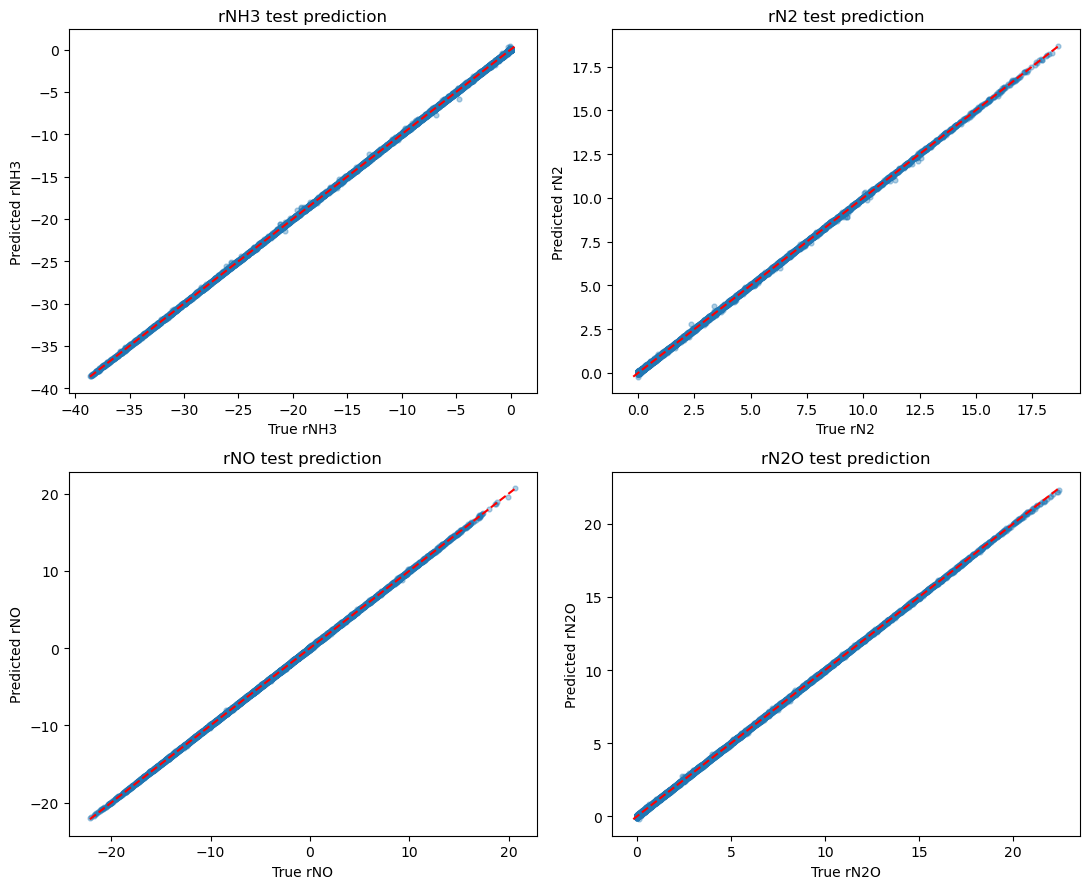

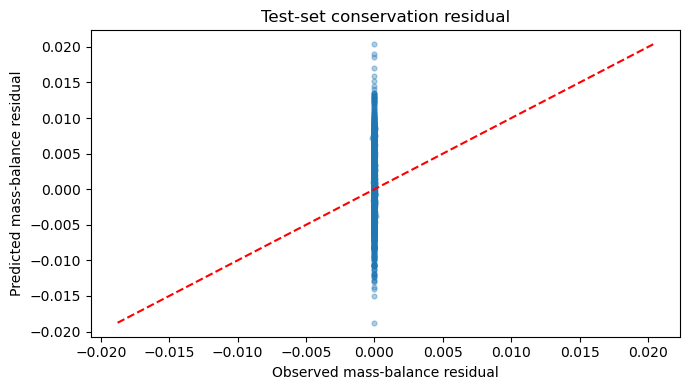

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for i, target in enumerate(TARGETS):
    ax = axes.flat[i]
    ax.scatter(y_test[:, i], test_predictions[:, i], alpha=0.35, s=12)
    lo = min(y_test[:, i].min(), test_predictions[:, i].min())
    hi = max(y_test[:, i].max(), test_predictions[:, i].max())
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_xlabel(f'True {target}')
    ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'{target} test prediction')
fig.tight_layout()
plt.show()

test_balance_residual = conservation_residual(test_predictions)
observed_test_balance = conservation_residual(y_test)
plt.figure(figsize=(7, 4))
plt.scatter(observed_test_balance, test_balance_residual, alpha=0.35, s=12)
lo = min(observed_test_balance.min(), test_balance_residual.min())
hi = max(observed_test_balance.max(), test_balance_residual.max())
plt.plot([lo, hi], [lo, hi], 'r--')
plt.xlabel('Observed mass-balance residual')
plt.ylabel('Predicted mass-balance residual')
plt.title('Test-set conservation residual')
plt.tight_layout()
plt.show()

## Architecture sweep at fixed penalty = 10

Before running the sweep, run the `model-training-helper` cell above once so the kernel loads the architecture-aware `train_shared_model` definition. You do not need to rerun the earlier comparisons. This first-pass sweep keeps the data split, optimizer, early stopping, and penalty fixed while changing hidden-layer width and depth. The existing 128×128 model is included as the baseline. Select by validation results only: `normalized_rmse` is the root mean square of each rate RMSE divided by that rate's training standard deviation; also inspect the per-rate errors and balance residual. These are screening runs with one seed, so rerun promising architectures with additional seeds before drawing a firm conclusion.

In [ ]:
ARCHITECTURE_PENALTY = 10.0
ARCHITECTURES = {
    '1x64': (64,),
    '2x64': (64, 64),
    '3x128': (128, 128, 128),
    '2x256': (256, 256),
}

if 'hidden_dims' not in train_shared_model.__code__.co_varnames:
    raise RuntimeError(
        'This kernel has the old training helper. Run the model-training-helper cell above, '
        'then rerun this architecture-sweep cell.'
    )

if 'SHARED_VALIDATION_PREDICTIONS' not in globals():
    SHARED_VALIDATION_PREDICTIONS = {}

for architecture_name, hidden_dims in ARCHITECTURES.items():
    model_name = f'architecture-{architecture_name}-penalty-10'
    train_shared_model(
        model_name,
        penalty_weight=ARCHITECTURE_PENALTY,
        hidden_dims=hidden_dims,
    )

architecture_rows = {}
for model_name, metrics in SHARED_RESULTS.items():
    if metrics.get('penalty_weight') != ARCHITECTURE_PENALTY:
        continue
    model = SHARED_MODELS.get(model_name)
    if model is None:
        raise RuntimeError(f'{model_name} has cached metrics but no in-memory model to recompute validation metrics.')
    if model_name not in SHARED_VALIDATION_PREDICTIONS:
        model.eval()
        with torch.no_grad():
            SHARED_VALIDATION_PREDICTIONS[model_name] = model(x_val_t).cpu().numpy()
    val_prediction = SHARED_VALIDATION_PREDICTIONS[model_name]
    metrics.update(score_rates(y_val, val_prediction))
    metrics.update(score_validation_errors(y_val, val_prediction))
    normalized_rmse = np.sqrt(np.mean([
        (metrics['rmse'][target] / target_scales[i]) ** 2
        for i, target in enumerate(TARGETS)
    ]))
    architecture_rows[model_name] = {
        'hidden_dims': '×'.join(map(str, metrics.get('hidden_dims', [WIDTH, WIDTH]))),
        'normalized_rmse': normalized_rmse,
        'balance_rmse': metrics['balance_rmse'],
        **{
            f'{target}_{metric_name}': metrics[metric_name][target]
            for target in TARGETS
            for metric_name in ('rmse', 'mae', 'r2', 'min_error', 'max_error', 'max_abs_error')
        },
    }

architecture_comparison = pd.DataFrame.from_dict(architecture_rows, orient='index')
display(architecture_comparison.sort_values('normalized_rmse'))

## Controlled capacity and optimization experiments (penalty = 10)

After changing this notebook, restart the kernel. Run from the top through the validation-comparison cells, skip `final-test-evaluation` and `test-plots`, then continue with the architecture and controlled-investigation cells at the end. This loads the new helper and result dictionaries without re-running the old test evaluation. Matched parameter counts let us compare depth against width more fairly: the configurations are grouped into two approximate capacity budgets. Parameter counts are reported so you can see exactly how close each match is. The final experiment holds the current best architecture (2×256) fixed and varies learning rate or weight decay one factor at a time. Rank by normalized validation RMSE, while also checking each rate and balance error. These are single-seed comparisons; confirm finalists with multiple seeds. The earlier saved test evaluation ran before these new architecture choices. Treat that test score as already observed, do not use it to choose a model, and do not rerun the test cell as part of this search. A fresh final estimate would require reserving new test data.

In [40]:
MATCHED_ARCHITECTURES = {
    'small-1x1962': (1962,),
    'small-2x128': (128, 128),
    'small-3x90': (90, 90, 90),
    'small-4x74': (74, 74, 74, 74),
    'large-2x256': (256, 256),
    'large-3x184': (184, 184, 184),
    'large-4x150': (150, 150, 150, 150),
}

if 'hidden_dims' not in train_shared_model.__code__.co_varnames:
    raise RuntimeError('Run the updated model-training-helper cell before this sweep.')

for architecture_name, hidden_dims in MATCHED_ARCHITECTURES.items():
    model_name = f'matched-{architecture_name}-penalty-10'
    if model_name in SHARED_MODELS and model_name in SHARED_RESULTS:
        continue
    train_shared_model(
        model_name,
        penalty_weight=10.0,
        hidden_dims=hidden_dims,
    )

matched_rows = {}
for model_name, metrics in SHARED_RESULTS.items():
    if not model_name.startswith('matched-'):
        continue
    model = SHARED_MODELS.get(model_name)
    if model is None:
        raise RuntimeError(
            f'{model_name} metrics exist without a trained model in this kernel. '
            'Restart and run the notebook through this sweep once.'
        )
    model.eval()
    if model_name not in SHARED_VALIDATION_PREDICTIONS:
        model.eval()
        with torch.no_grad():
            SHARED_VALIDATION_PREDICTIONS[model_name] = model(x_val_t).cpu().numpy()
    val_prediction = SHARED_VALIDATION_PREDICTIONS[model_name]
    val_error = val_prediction - y_val
    val_rmse = np.sqrt(np.mean(val_error ** 2, axis=0))
    val_mae = np.mean(np.abs(val_error), axis=0)
    total_sum_squares = np.sum((y_val - y_val.mean(axis=0)) ** 2, axis=0)
    residual_sum_squares = np.sum(val_error ** 2, axis=0)
    val_r2 = np.full(len(TARGETS), np.nan, dtype=np.float64)
    np.divide(residual_sum_squares, total_sum_squares, out=val_r2, where=total_sum_squares > 0)
    val_r2 = np.where(total_sum_squares > 0, 1.0 - val_r2, np.nan)
    normalized_rmse = np.sqrt(np.mean([
        (val_rmse[i] / target_scales[i]) ** 2
        for i, target in enumerate(TARGETS)
    ]))
    hidden_dims = metrics['hidden_dims']
    parameter_count = sum(
        (input_dim + 1) * output_dim
        for input_dim, output_dim in zip(
            [len(FEATURES), *hidden_dims],
            [*hidden_dims, len(TARGETS)],
        )
    )
    matched_rows[model_name] = {
        'hidden_dims': '×'.join(map(str, hidden_dims)),
        'parameter_count': parameter_count,
        'normalized_rmse': normalized_rmse,
        'balance_rmse': float(np.sqrt(np.mean(conservation_residual(val_prediction) ** 2))),
        **{
            f'{target}_{metric_name}': values[i]
            for i, target in enumerate(TARGETS)
            for metric_name, values in (
                ('rmse', val_rmse),
                ('mae', val_mae),
                ('r2', val_r2),
                ('min_error', val_error.min(axis=0)),
                ('max_error', val_error.max(axis=0)),
                ('max_abs_error', np.abs(val_error).max(axis=0)),
            )
        },
    }

matched_comparison = pd.DataFrame.from_dict(matched_rows, orient='index')
display(matched_comparison.sort_values(['parameter_count', 'normalized_rmse']))

Saved shared model 'matched-small-1x1962-penalty-10' to /home/afe/projects/model_checkpoints/shared-ed9523f8eb9d3efb.pt
matched-small-1x1962-penalty-10 {'rmse': {'rNH3': 0.12118645190832064, 'rN2': 0.05933226616533918, 'rNO': 0.10619017703795791, 'rN2O': 0.07557140637456203}, 'mae': {'rNH3': 0.07682940546776683, 'rN2': 0.035205585162980134, 'rNO': 0.06345503879982035, 'rN2O': 0.04576913327714588}, 'balance_rmse': 0.0066674215094955245, 'observed_balance_rmse': 1.291472824016521e-06, 'r2': {'rNH3': 0.9998610611261944, 'rN2': 0.9997074813041046, 'rNO': 0.9996745819736276, 'rN2O': 0.9997461893014615}, 'min_error': {'rNH3': -3.259495616249943, 'rN2': -0.7121681309171795, 'rNO': -1.3462144505148381, 'rN2O': -1.0287134860596412}, 'max_error': {'rNH3': 1.0045780513968516, 'rN2': 1.3629606168225097, 'rNO': 1.6489853974719573, 'rN2O': 0.9301693461257043}, 'max_abs_error': {'rNH3': 3.259495616249943, 'rN2': 1.3629606168225097, 'rNO': 1.6489853974719573, 'rN2O': 1.0287134860596412}, 'penalty_weig

,hidden_dims,parameter_count,normalized_rmse,balance_rmse,rNH3_rmse,rNH3_mae,rNH3_r2,rNH3_min_error,rNH3_max_error,rNH3_max_abs_error,rN2_rmse,rN2_mae,rN2_r2,rN2_min_error,rN2_max_error,rN2_max_abs_error,rNO_rmse,rNO_mae,rNO_r2,rNO_min_error,rNO_max_error,rNO_max_abs_error,rN2O_rmse,rN2O_mae,rN2O_r2,rN2O_min_error,rN2O_max_error,rN2O_max_abs_error
matched-small-3x90-penalty-10,90×90×90,17194,0.006813,0.005446,0.058313,0.039915,0.999968,-0.983271,0.541725,0.983271,0.024897,0.016184,0.999948,-0.315988,0.468865,0.468865,0.046880,0.032518,0.999937,-0.388731,0.392237,0.392237,0.029127,0.020962,0.999962,-0.206812,0.239608,0.239608
matched-small-4x74-penalty-10,74×74×74×74,17320,0.007275,0.003227,0.061854,0.044903,0.999964,-0.591030,0.782224,0.782224,0.025549,0.017214,0.999946,-0.392864,0.223807,0.392864,0.050135,0.032256,0.999927,-0.430123,0.624278,0.624278,0.032807,0.023782,0.999952,-0.200430,0.257200,0.257200
matched-small-1x1962-penalty-10,1962,17662,0.015932,0.006667,0.121186,0.076829,0.999861,-3.259496,1.004578,3.259496,0.059332,0.035206,0.999707,-0.712168,1.362961,1.362961,0.106190,0.063455,0.999675,-1.346214,1.648985,1.648985,0.075571,0.045769,0.999746,-1.028713,0.930169,1.028713
matched-small-2x128-penalty-10,128×128,17668,0.007172,0.002879,0.058945,0.041558,0.999967,-1.290118,0.581161,1.290118,0.026975,0.017836,0.999940,-0.302443,0.557951,0.557951,0.047141,0.032528,0.999936,-0.691386,0.387103,0.691386,0.032621,0.024147,0.999953,-0.209905,0.292730,0.292730
matched-large-2x256-penalty-10,256×256,68100,0.004514,0.001778,0.037700,0.027783,0.999987,-0.666941,0.467788,0.666941,0.016580,0.011385,0.999977,-0.310731,0.322840,0.322840,0.031694,0.022080,0.999971,-0.227842,0.276546,0.276546,0.018878,0.013973,0.999984,-0.125102,0.133097,0.133097
matched-large-4x150-penalty-10,150×150×150×150,69304,0.005384,0.003516,0.047074,0.033331,0.999979,-0.554994,0.417575,0.554994,0.017745,0.011381,0.999974,-0.220735,0.249444,0.249444,0.037583,0.023908,0.999959,-0.313502,0.220987,0.313502,0.024932,0.017761,0.999972,-0.132875,0.117219,0.132875
matched-large-3x184-penalty-10,184×184×184,69740,0.004805,0.003453,0.040536,0.028199,0.999984,-0.353952,0.469446,0.469446,0.016844,0.010945,0.999976,-0.336357,0.183013,0.336357,0.032564,0.022406,0.999969,-0.346866,0.297104,0.346866,0.022379,0.016314,0.999978,-0.121055,0.176191,0.176191


In [28]:
# Set True only when you want to train the four additional tuning models.
RUN_TUNING_EXPERIMENTS = False

if not RUN_TUNING_EXPERIMENTS:
    print('Training-settings sweep skipped. Set RUN_TUNING_EXPERIMENTS = True to opt in.')
else:
    TUNING_ARCHITECTURE = (256, 256)
    TUNING_SETTINGS = {
        'lr-3e-4-wd-1e-5': (3e-4, 1e-5),
        'lr-3e-3-wd-1e-5': (3e-3, 1e-5),
        'lr-1e-3-wd-1e-6': (1e-3, 1e-6),
        'lr-1e-3-wd-1e-4': (1e-3, 1e-4),
    }

    if not {'hidden_dims', 'learning_rate', 'weight_decay'}.issubset(train_shared_model.__code__.co_varnames):
        raise RuntimeError('Run the updated model-training-helper cell before opting into this tuning sweep.')

    for setting_name, (learning_rate, weight_decay) in TUNING_SETTINGS.items():
        model_name = f'tune-2x256-{setting_name}-penalty-10'
        train_shared_model(
            model_name,
            penalty_weight=10.0,
            hidden_dims=TUNING_ARCHITECTURE,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
        )

    tuning_names = ['architecture-2x256-penalty-10'] + [
        f'tune-2x256-{setting_name}-penalty-10' for setting_name in TUNING_SETTINGS
    ]
    tuning_rows = {}
    for model_name in tuning_names:
        if model_name not in SHARED_RESULTS:
            continue
        metrics = SHARED_RESULTS[model_name]
        normalized_rmse = np.sqrt(np.mean([
            (metrics['rmse'][target] / target_scales[i]) ** 2
            for i, target in enumerate(TARGETS)
        ]))
        tuning_rows[model_name] = {
            'learning_rate': metrics.get('learning_rate', LEARNING_RATE),
            'weight_decay': metrics.get('weight_decay', 1e-5),
            'normalized_rmse': normalized_rmse,
            'balance_rmse': metrics['balance_rmse'],
            **{
                f'{target}_{metric_name}': metrics[metric_name][target]
                for target in TARGETS
                for metric_name in ('rmse', 'mae', 'r2', 'min_error', 'max_error', 'max_abs_error')
            },
        }

    tuning_comparison = pd.DataFrame.from_dict(tuning_rows, orient='index')
    display(tuning_comparison.sort_values('normalized_rmse'))

Training-settings sweep skipped. Set RUN_TUNING_EXPERIMENTS = True to opt in.


## Wide single-layer and activation experiments

This opt-in sweep compares wider one-hidden-layer models with ReLU, then compares ReLU, GELU, SiLU, and tanh at a fixed width of 1962. The data split, penalty, optimizer, and seed stay fixed; all scores are computed on validation data. Set the flag in the following cell to `True` only when you want to train these models. Re-running the cell reuses cached same-configuration models.

In [ ]:
RUN_WIDE_ACTIVATION_EXPERIMENTS = True

if not RUN_WIDE_ACTIVATION_EXPERIMENTS:
    print('Wide single-layer and activation experiments skipped. Set RUN_WIDE_ACTIVATION_EXPERIMENTS = True to opt in.')
else:
    if not {'hidden_dims', 'activation'}.issubset(train_shared_model.__code__.co_varnames):
        raise RuntimeError('Run the updated model-training-helper cell before opting into these experiments.')

    WIDE_LAYER_WIDTHS = (1962, 3072, 4096, 6144)
    ACTIVATION_COMPARISON_WIDTH = 1962
    experiment_configs = {
        f'wide-1x{width}-relu-penalty-10': ((width,), 'relu')
        for width in WIDE_LAYER_WIDTHS
    }
    experiment_configs.update({
        f'activation-1x{ACTIVATION_COMPARISON_WIDTH}-{activation}-penalty-10': (
            (ACTIVATION_COMPARISON_WIDTH,), activation
        )
        for activation in ('gelu', 'silu', 'tanh')
    })

    for model_name, (hidden_dims, activation) in experiment_configs.items():
        train_shared_model(
            model_name,
            penalty_weight=10.0,
            hidden_dims=hidden_dims,
            activation=activation,
        )

    wide_activation_rows = {}
    for model_name in experiment_configs:
        metrics = SHARED_RESULTS[model_name]
        wide_activation_rows[model_name] = {
            'hidden_dims': '×'.join(map(str, metrics['hidden_dims'])),
            'activation': metrics['activation'],
            'parameter_count': metrics['parameter_count'],
            'best_epoch': metrics['best_epoch'],
            'val_objective': metrics['val_objective'],
            'normalized_rmse': np.sqrt(np.mean([
                (metrics['rmse'][target] / target_scales[i]) ** 2
                for i, target in enumerate(TARGETS)
            ])),
            'balance_rmse': metrics['balance_rmse'],
            **{
                f'{target}_{metric_name}': metrics[metric_name][target]
                for target in TARGETS
                for metric_name in ('rmse', 'mae', 'r2', 'max_abs_error')
            },
        }

    wide_activation_comparison = pd.DataFrame.from_dict(wide_activation_rows, orient='index')
    display(wide_activation_comparison.sort_values('normalized_rmse'))

wide-1x1962-relu-penalty-10 {'rmse': {'rNH3': 0.12118645190832064, 'rN2': 0.05933226616533918, 'rNO': 0.10619017703795791, 'rN2O': 0.07557140637456203}, 'mae': {'rNH3': 0.07682940546776683, 'rN2': 0.035205585162980134, 'rNO': 0.06345503879982035, 'rN2O': 0.04576913327714588}, 'balance_rmse': 0.0066674215094955245, 'observed_balance_rmse': 1.291472824016521e-06, 'r2': {'rNH3': 0.9998610611261944, 'rN2': 0.9997074813041046, 'rNO': 0.9996745819736276, 'rN2O': 0.9997461893014615}, 'min_error': {'rNH3': -3.259495616249943, 'rN2': -0.7121681309171795, 'rNO': -1.3462144505148381, 'rN2O': -1.0287134860596412}, 'max_error': {'rNH3': 1.0045780513968516, 'rN2': 1.3629606168225097, 'rNO': 1.6489853974719573, 'rN2O': 0.9301693461257043}, 'max_abs_error': {'rNH3': 3.259495616249943, 'rN2': 1.3629606168225097, 'rNO': 1.6489853974719573, 'rN2O': 1.0287134860596412}, 'penalty_weight': 10.0, 'hidden_dims': [1962], 'parameter_count': 17662, 'learning_rate': 0.001, 'weight_decay': 1e-05, 'activation': 're

## Deeper networks with exact mass conservation

These matched-capacity models compare two, three, and four hidden layers while enforcing the mass-balance equation in the model output. The projection minimizes the change from the raw network outputs in training-standard-deviation-scaled coordinates; accuracy is therefore the training and early-stopping objective, with no soft balance penalty. Predictions are returned in float64 after projection to reduce roundoff. The observed labels have a tiny nonzero balance residual, so exact predictions may differ from labels by that irreducible amount. This opt-in screen uses the existing train/validation split and seed and does not train unless enabled.

In [41]:
RUN_EXACT_BALANCE_DEPTH_EXPERIMENTS = True

if not RUN_EXACT_BALANCE_DEPTH_EXPERIMENTS:
    print('Exact-balance depth sweep skipped. Set RUN_EXACT_BALANCE_DEPTH_EXPERIMENTS = True to opt in.')
else:
    import copy

    class ExactBalanceDepthNetwork(nn.Module):
        def __init__(self, hidden_dims):
            super().__init__()
            layers = []
            input_dim = len(FEATURES)
            for hidden_dim in hidden_dims:
                layers.extend([nn.Linear(input_dim, hidden_dim), nn.ReLU()])
                input_dim = hidden_dim
            layers.append(nn.Linear(input_dim, len(TARGETS)))
            self.layers = nn.Sequential(*layers)
            self.register_buffer(
                'balance_coefficients',
                torch.as_tensor(BALANCE_COEFFICIENTS, dtype=torch.float64),
            )
            self.register_buffer(
                'projection_variances',
                torch.as_tensor(np.square(target_scales), dtype=torch.float64),
            )
            self.projection_denominator = float(np.sum(BALANCE_COEFFICIENTS ** 2 * target_scales ** 2))

        def forward(self, x):
            prediction = self.layers(x).to(torch.float64)
            residual = prediction @ self.balance_coefficients
            correction = (residual / self.projection_denominator).unsqueeze(1)
            return prediction - correction * self.projection_variances * self.balance_coefficients

    if 'SHARED_MODELS' not in globals():
        SHARED_MODELS = {}
    if 'SHARED_RESULTS' not in globals():
        SHARED_RESULTS = {}
    if 'SHARED_VALIDATION_PREDICTIONS' not in globals():
        SHARED_VALIDATION_PREDICTIONS = {}

    EXACT_BALANCE_ARCHITECTURES = {
        '2x256': (256, 256),
        '3x184': (184, 184, 184),
        '4x150': (150, 150, 150, 150),
    }
    x_exact_train = torch.as_tensor(x_train, dtype=torch.float32, device=device)
    x_exact_val = torch.as_tensor(x_val, dtype=torch.float32, device=device)
    y_exact_train = torch.as_tensor(y_train, dtype=torch.float32, device=device)
    y_exact_val = torch.as_tensor(y_val, dtype=torch.float32, device=device)
    exact_train_loader = DataLoader(
        TensorDataset(x_exact_train, y_exact_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )

    for architecture_name, hidden_dims in EXACT_BALANCE_ARCHITECTURES.items():
        model_name = f'exact-balance-{architecture_name}'
        cached_model = SHARED_MODELS.get(model_name)
        cached_metrics = SHARED_RESULTS.get(model_name, {})
        is_matching_cache = (
            cached_model is not None
            and cached_metrics.get('enforce_balance') is True
            and cached_metrics.get('hidden_dims') == list(hidden_dims)
            and cached_metrics.get('activation', 'relu') == 'relu'
        )

        if is_matching_cache:
            model = cached_model
            print(f'{model_name}: reusing cached exact-balance model')
        else:
            torch.manual_seed(SEED)
            model = ExactBalanceDepthNetwork(hidden_dims).to(device)
            optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
            best_val, best_state, best_epoch, wait = float('inf'), None, 0, 0

            for epoch in range(MAX_EPOCHS):
                model.train()
                for xb, yb in exact_train_loader:
                    optimizer.zero_grad(set_to_none=True)
                    prediction = model(xb)
                    loss = (((prediction - yb) / torch.as_tensor(target_scales, dtype=torch.float32, device=device)) ** 2).mean()
                    if not torch.isfinite(loss):
                        raise FloatingPointError(f'{model_name}: non-finite training loss at epoch {epoch + 1}')
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

                model.eval()
                with torch.no_grad():
                    val_loss_sum = 0.0
                    val_count = 0
                    for start in range(0, len(x_exact_val), BATCH_SIZE):
                        stop = start + BATCH_SIZE
                        prediction = model(x_exact_val[start:stop])
                        batch_loss = (((prediction - y_exact_val[start:stop]) / torch.as_tensor(target_scales, dtype=torch.float32, device=device)) ** 2).mean()
                        val_loss_sum += batch_loss.item() * (stop - start)
                        val_count += stop - start
                val_loss = val_loss_sum / val_count
                if val_loss < best_val - 1e-8:
                    best_val = val_loss
                    best_state = copy.deepcopy(model.state_dict())
                    best_epoch, wait = epoch + 1, 0
                else:
                    wait += 1
                    if wait >= PATIENCE:
                        break

            if best_state is None:
                raise RuntimeError(f'{model_name}: training produced no valid checkpoint')
            model.load_state_dict(best_state)
            SHARED_MODELS[model_name] = model
            print(f'{model_name}: best epoch {best_epoch}')

        model.eval()
        with torch.no_grad():
            val_prediction = model(x_exact_val).cpu().numpy()
        error = val_prediction - y_val
        residual = conservation_residual(val_prediction)
        rmse = np.sqrt(np.mean(error ** 2, axis=0))
        mae = np.mean(np.abs(error), axis=0)
        total_sum_squares = np.sum((y_val - y_val.mean(axis=0)) ** 2, axis=0)
        residual_sum_squares = np.sum(error ** 2, axis=0)
        r2 = np.full(len(TARGETS), np.nan, dtype=np.float64)
        np.divide(residual_sum_squares, total_sum_squares, out=r2, where=total_sum_squares > 0)
        r2 = np.where(total_sum_squares > 0, 1.0 - r2, np.nan)
        metrics = {
            'rmse': dict(zip(TARGETS, rmse.tolist())),
            'mae': dict(zip(TARGETS, mae.tolist())),
            'r2': dict(zip(TARGETS, r2.tolist())),
            'min_error': dict(zip(TARGETS, error.min(axis=0).tolist())),
            'max_error': dict(zip(TARGETS, error.max(axis=0).tolist())),
            'max_abs_error': dict(zip(TARGETS, np.abs(error).max(axis=0).tolist())),
            'balance_rmse': float(np.sqrt(np.mean(residual ** 2))),
            'observed_balance_rmse': float(np.sqrt(np.mean(conservation_residual(y_val) ** 2))),
            'penalty_weight': 0.0,
            'enforce_balance': True,
            'hidden_dims': list(hidden_dims),
            'parameter_count': sum(parameter.numel() for parameter in model.parameters()),
            'learning_rate': LEARNING_RATE,
            'weight_decay': 1e-5,
            'activation': 'relu',
            'best_epoch': best_epoch if not is_matching_cache else cached_metrics.get('best_epoch'),
            'val_objective': best_val if not is_matching_cache else cached_metrics.get('val_objective'),
        }
        SHARED_RESULTS[model_name] = metrics
        SHARED_VALIDATION_PREDICTIONS[model_name] = val_prediction.copy()
        save_model_checkpoint(
            kind='shared',
            name=model_name,
            model_states=model.state_dict(),
            metrics=metrics,
            validation_prediction=val_prediction,
            config={
                'hidden_dims': list(hidden_dims),
                'activation': 'relu',
                'enforce_balance': True,
            },
        )

    exact_balance_rows = {}
    for architecture_name, hidden_dims in EXACT_BALANCE_ARCHITECTURES.items():
        model_name = f'exact-balance-{architecture_name}'
        metrics = SHARED_RESULTS[model_name]
        val_prediction = SHARED_VALIDATION_PREDICTIONS[model_name]
        exact_balance_rows[model_name] = {
            'hidden_dims': '×'.join(map(str, metrics['hidden_dims'])),
            'parameter_count': metrics['parameter_count'],
            'best_epoch': metrics['best_epoch'],
            'validation_normalized_rmse': np.sqrt(np.mean([
                (metrics['rmse'][target] / target_scales[i]) ** 2
                for i, target in enumerate(TARGETS)
            ])),
            'validation_balance_rmse': metrics['balance_rmse'],
            'validation_max_abs_balance_residual': float(np.max(np.abs(conservation_residual(val_prediction)))),
            **{
                f'{target}_{metric_name}': metrics[metric_name][target]
                for target in TARGETS
                for metric_name in ('rmse', 'mae', 'r2', 'max_abs_error')
            },
        }

    exact_balance_comparison = pd.DataFrame.from_dict(exact_balance_rows, orient='index')
    display(exact_balance_comparison.sort_values('validation_normalized_rmse'))

exact-balance-2x256: reusing cached exact-balance model
Saved shared model 'exact-balance-2x256' to /home/afe/projects/model_checkpoints/shared-d57ccd3325a12452.pt
exact-balance-3x184: reusing cached exact-balance model
Saved shared model 'exact-balance-3x184' to /home/afe/projects/model_checkpoints/shared-92c3857712560629.pt
exact-balance-4x150: reusing cached exact-balance model
Saved shared model 'exact-balance-4x150' to /home/afe/projects/model_checkpoints/shared-21278412fcbda018.pt


,hidden_dims,parameter_count,best_epoch,validation_normalized_rmse,validation_balance_rmse,validation_max_abs_balance_residual,rNH3_rmse,rNH3_mae,rNH3_r2,rNH3_max_abs_error,rN2_rmse,rN2_mae,rN2_r2,rN2_max_abs_error,rNO_rmse,rNO_mae,rNO_r2,rNO_max_abs_error,rN2O_rmse,rN2O_mae,rN2O_r2,rN2O_max_abs_error
exact-balance-2x256,256×256,68100,186,0.004587,2.335481e-15,1.421085e-14,0.036986,0.027106,0.999987,0.472664,0.016989,0.011664,0.999976,0.219676,0.030394,0.021719,0.999973,0.261944,0.021324,0.016232,0.999980,0.150281
exact-balance-3x184,184×184×184,69740,160,0.004781,2.330853e-15,1.421085e-14,0.039276,0.027473,0.999985,0.855552,0.017119,0.011328,0.999976,0.408424,0.033157,0.023653,0.999968,0.396824,0.021417,0.015741,0.999980,0.114930
exact-balance-4x150,150×150×150×150,69304,155,0.005268,2.362240e-15,1.421085e-14,0.043133,0.029663,0.999982,0.564533,0.020172,0.013909,0.999966,0.277792,0.035055,0.022499,0.999965,0.341697,0.023035,0.016582,0.999976,0.142134


## Plot validation performance across cached models

This cell visualizes validation-only metrics already stored in `SHARED_RESULTS`; it does not train models. The first plot shows the trade-off between rate accuracy and balance residual. The second compares per-rate normalized RMSE for the models with the smallest balance residuals.

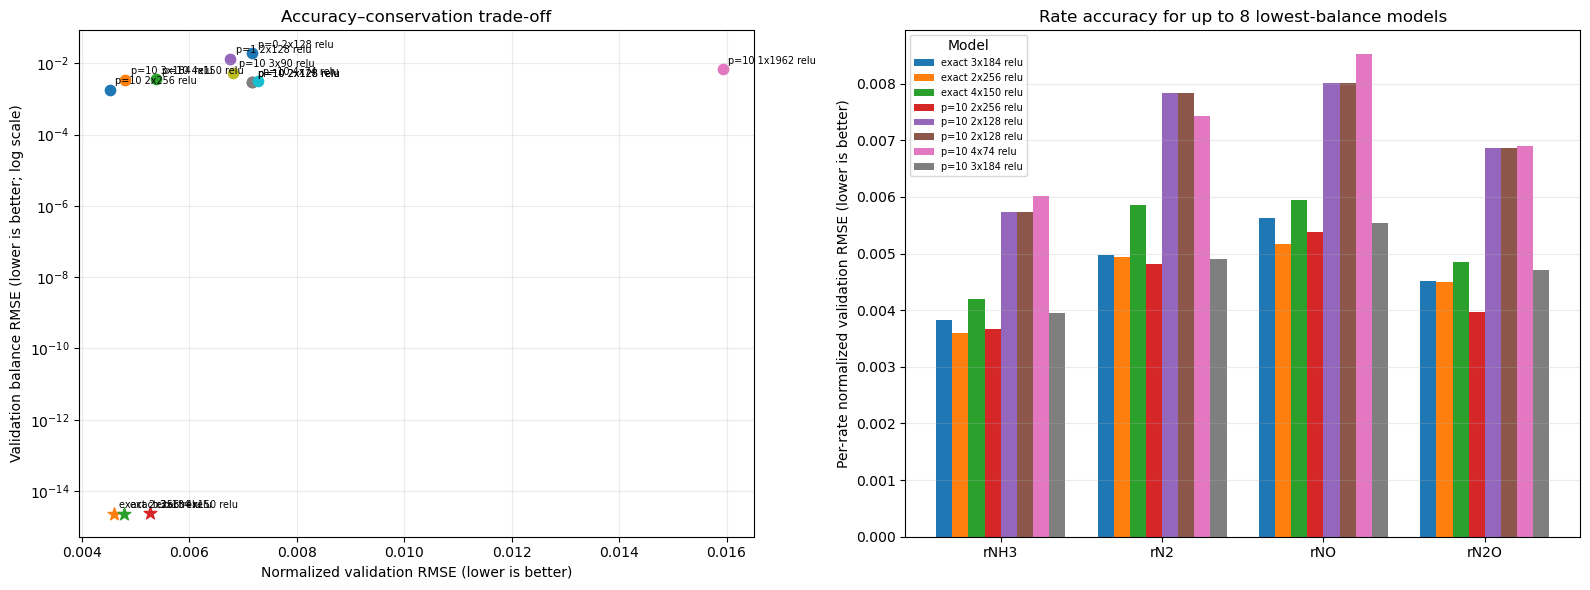

In [42]:
plot_rows = []
for model_name, metrics in SHARED_RESULTS.items():
    if 'rmse' not in metrics or 'balance_rmse' not in metrics:
        continue
    if not all(target in metrics['rmse'] for target in TARGETS):
        continue
    normalized_rmse = np.sqrt(np.mean([
        (metrics['rmse'][target] / target_scales[i]) ** 2
        for i, target in enumerate(TARGETS)
    ]))
    hidden_dims = metrics.get('hidden_dims', [WIDTH, WIDTH])
    penalty_weight = metrics.get('penalty_weight')
    activation = metrics.get('activation', 'relu')
    exact_balance = metrics.get('enforce_balance', False)
    label = f"{'exact' if exact_balance else f'p={penalty_weight:g}'} {len(hidden_dims)}x{hidden_dims[0]} {activation}"
    plot_rows.append({
        'name': model_name,
        'label': label,
        'metrics': metrics,
        'normalized_rmse': normalized_rmse,
        'balance_rmse': metrics['balance_rmse'],
        'exact_balance': exact_balance,
    })

if not plot_rows:
    print('No cached shared-model validation results are available to plot yet.')
else:
    fig, (ax_tradeoff, ax_rates) = plt.subplots(1, 2, figsize=(16, 6))
    for row in plot_rows:
        ax_tradeoff.scatter(
            row['normalized_rmse'],
            max(row['balance_rmse'], np.finfo(float).tiny),
            marker='*' if row['exact_balance'] else 'o',
            s=90 if row['exact_balance'] else 55,
            label=row['label'],
        )
        ax_tradeoff.annotate(
            row['label'],
            (row['normalized_rmse'], max(row['balance_rmse'], np.finfo(float).tiny)),
            xytext=(4, 4),
            textcoords='offset points',
            fontsize=7,
        )
    ax_tradeoff.set_yscale('log')
    ax_tradeoff.set_xlabel('Normalized validation RMSE (lower is better)')
    ax_tradeoff.set_ylabel('Validation balance RMSE (lower is better; log scale)')
    ax_tradeoff.set_title('Accuracy–conservation trade-off')
    ax_tradeoff.grid(True, which='both', alpha=0.25)

    best_balance_rows = sorted(plot_rows, key=lambda row: row['balance_rmse'])[:8]
    x_positions = np.arange(len(TARGETS))
    bar_width = 0.8 / len(best_balance_rows)
    for row_index, row in enumerate(best_balance_rows):
        rate_rmse = [
            row['metrics']['rmse'][target] / target_scales[target_index]
            for target_index, target in enumerate(TARGETS)
        ]
        offsets = x_positions - 0.4 + bar_width * (row_index + 0.5)
        ax_rates.bar(offsets, rate_rmse, bar_width, label=row['label'])
    ax_rates.set_xticks(x_positions, TARGETS)
    ax_rates.set_ylabel('Per-rate normalized validation RMSE (lower is better)')
    ax_rates.set_title('Rate accuracy for up to 8 lowest-balance models')
    ax_rates.grid(True, axis='y', alpha=0.25)
    ax_rates.legend(fontsize=7, title='Model', loc='best')
    fig.tight_layout()
    plt.show()

## Search for stronger exact-conservation configurations

This opt-in, two-stage sweep enforces conservation by projection in every candidate. Stage 1 compares four wider/deeper architectures with ReLU, GELU, and SiLU; stage 2 tries alternate learning rates for the three best validation configurations. Selection uses validation normalized RMSE only, and displays the maximum validation conservation residual as a numerical check. The test split is not used. The sweep may take a while; completed models are checkpointed automatically.

In [44]:
RUN_EXACT_CONSERVATION_MODEL_SEARCH = True

if not RUN_EXACT_CONSERVATION_MODEL_SEARCH:
    print('Exact-conservation model search skipped. Set RUN_EXACT_CONSERVATION_MODEL_SEARCH = True to opt in.')
else:
    required_parameters = {'hidden_dims', 'activation', 'learning_rate', 'weight_decay', 'enforce_balance'}
    if not required_parameters.issubset(train_shared_model.__code__.co_varnames):
        raise RuntimeError('Run the updated model-training-helper cell before this sweep.')

    SEARCH_ARCHITECTURES = {
        '2x384': (384, 384),
        '3x256': (256, 256, 256),
        '4x192': (192, 192, 192, 192),
        '5x160': (160, 160, 160, 160, 160),
    }
    SEARCH_ACTIVATIONS = ('relu', 'gelu', 'silu')
    SEARCH_REFINE_TOP = 3
    SEARCH_REFINE_LEARNING_RATES = (3e-4, 3e-3)

    def exact_search_row(model_name, metrics):
        prediction = SHARED_VALIDATION_PREDICTIONS[model_name]
        per_rate_normalized_rmse = [
            metrics['rmse'][target] / target_scales[index]
            for index, target in enumerate(TARGETS)
        ]
        return {
            'model': model_name,
            'architecture': 'x'.join(map(str, metrics['hidden_dims'])),
            'activation': metrics['activation'],
            'learning_rate': metrics['learning_rate'],
            'weight_decay': metrics['weight_decay'],
            'parameter_count': metrics['parameter_count'],
            'best_epoch': metrics['best_epoch'],
            'validation_normalized_rmse': float(np.sqrt(np.mean(np.square(per_rate_normalized_rmse)))),
            'validation_balance_rmse': float(np.sqrt(np.mean(np.square(conservation_residual(prediction))))),
            'validation_max_abs_balance_residual': float(np.max(np.abs(conservation_residual(prediction)))),
            **{
                f'{target}_normalized_rmse': per_rate_normalized_rmse[index]
                for index, target in enumerate(TARGETS)
            },
        }

    stage_one_names = []
    for architecture_name, hidden_dims in SEARCH_ARCHITECTURES.items():
        for activation in SEARCH_ACTIVATIONS:
            model_name = f'exact-search-stage1-{architecture_name}-{activation}'
            train_shared_model(
                model_name,
                penalty_weight=0.0,
                hidden_dims=hidden_dims,
                activation=activation,
                enforce_balance=True,
            )
            stage_one_names.append(model_name)

    stage_one_results = [
        exact_search_row(name, SHARED_RESULTS[name])
        for name in stage_one_names
    ]
    stage_one_comparison = pd.DataFrame(stage_one_results).sort_values('validation_normalized_rmse')
    display(stage_one_comparison)

    finalists = stage_one_comparison.head(SEARCH_REFINE_TOP)
    for _, finalist in finalists.iterrows():
        architecture_name = next(
            key for key, dims in SEARCH_ARCHITECTURES.items()
            if list(dims) == SHARED_RESULTS[finalist['model']]['hidden_dims']
        )
        hidden_dims = SEARCH_ARCHITECTURES[architecture_name]
        activation = finalist['activation']
        for learning_rate in SEARCH_REFINE_LEARNING_RATES:
            learning_rate_tag = f'{learning_rate:.0e}'.replace('+', '')
            model_name = f'exact-search-stage2-{architecture_name}-{activation}-lr-{learning_rate_tag}'
            train_shared_model(
                model_name,
                penalty_weight=0.0,
                hidden_dims=hidden_dims,
                activation=activation,
                learning_rate=learning_rate,
                enforce_balance=True,
            )

    all_search_names = stage_one_names + [
        name for name in SHARED_RESULTS
        if name.startswith('exact-search-stage2-')
    ]
    search_results = [
        exact_search_row(name, SHARED_RESULTS[name])
        for name in dict.fromkeys(all_search_names)
    ]
    exact_conservation_search_results = pd.DataFrame(search_results).sort_values('validation_normalized_rmse')
    if (exact_conservation_search_results['validation_max_abs_balance_residual'] > 1e-10).any():
        raise RuntimeError('An exact-conservation candidate exceeded the 1e-10 validation residual tolerance.')
    display(exact_conservation_search_results)
    print('Top validation configuration:', exact_conservation_search_results.iloc[0]['model'])

Saved shared model 'exact-search-stage1-2x384-relu' to /home/afe/projects/model_checkpoints/shared-74e8215c6a98c7e6.pt
exact-search-stage1-2x384-relu {'rmse': {'rNH3': 0.03047534252947946, 'rN2': 0.012749327132699696, 'rNO': 0.025312715788181693, 'rN2O': 0.016786083854885482}, 'mae': {'rNH3': 0.02247415475199145, 'rN2': 0.008802483661980913, 'rNO': 0.018227628009658672, 'rN2O': 0.012507189453906876}, 'balance_rmse': 2.0364920055476873e-15, 'observed_balance_rmse': 1.291472824016521e-06, 'r2': {'rNH3': 0.999991213562489, 'rN2': 0.9999864933923148, 'rNO': 0.9999815094255838, 'rN2O': 0.9999874774235405}, 'min_error': {'rNH3': -0.486082180171465, 'rN2': -0.14957212083851523, 'rNO': -0.2447597476992609, 'rN2O': -0.11132893233856933}, 'max_error': {'rNH3': 0.48017594136095987, 'rN2': 0.2790718968898718, 'rNO': 0.20445745837281204, 'rN2O': 0.08160749385024424}, 'max_abs_error': {'rNH3': 0.486082180171465, 'rN2': 0.2790718968898718, 'rNO': 0.2447597476992609, 'rN2O': 0.11132893233856933}, 'pen

,model,architecture,activation,learning_rate,weight_decay,parameter_count,best_epoch,validation_normalized_rmse,validation_balance_rmse,validation_max_abs_balance_residual,rNH3_normalized_rmse,rN2_normalized_rmse,rNO_normalized_rmse,rN2O_normalized_rmse
10,exact-search-stage1-5x160-gelu,160x160x160x160x160,gelu,0.001,0.00001,104484,189,0.001436,2.159898e-15,1.421085e-14,0.001361,0.001631,0.001543,0.001163
7,exact-search-stage1-4x192-gelu,192x192x192x192,gelu,0.001,0.00001,112900,125,0.001459,2.534042e-15,1.421085e-14,0.001188,0.001566,0.001768,0.001234
5,exact-search-stage1-3x256-silu,256x256x256,silu,0.001,0.00001,133892,172,0.001510,2.402477e-15,1.509903e-14,0.001336,0.001502,0.001656,0.001529
4,exact-search-stage1-3x256-gelu,256x256x256,gelu,0.001,0.00001,133892,120,0.001584,2.483253e-15,1.421085e-14,0.001270,0.001830,0.001712,0.001463
11,exact-search-stage1-5x160-silu,160x160x160x160x160,silu,0.001,0.00001,104484,141,0.001733,2.219511e-15,1.421085e-14,0.001375,0.001828,0.001953,0.001721
8,exact-search-stage1-4x192-silu,192x192x192x192,silu,0.001,0.00001,112900,80,0.002343,2.648813e-15,1.687539e-14,0.001898,0.002280,0.002789,0.002321
1,exact-search-stage1-2x384-gelu,384x384,gelu,0.001,0.00001,151300,207,0.002862,2.017851e-15,1.421085e-14,0.001947,0.003110,0.003459,0.002710
0,exact-search-stage1-2x384-relu,384x384,relu,0.001,0.00001,151300,176,0.003658,2.036492e-15,1.509903e-14,0.002968,0.003706,0.004300,0.003534
3,exact-search-stage1-3x256-relu,256x256x256,relu,0.001,0.00001,133892,189,0.003800,2.433607e-15,1.421085e-14,0.003427,0.003980,0.004228,0.003509
2,exact-search-stage1-2x384-silu,384x384,silu,0.001,0.00001,151300,234,0.003845,1.853728e-15,1.421085e-14,0.002560,0.004084,0.004732,0.003676


Saved shared model 'exact-search-stage2-5x160-gelu-lr-3e-04' to /home/afe/projects/model_checkpoints/shared-a8df7348abb59e11.pt
exact-search-stage2-5x160-gelu-lr-3e-04 {'rmse': {'rNH3': 0.013339542875882474, 'rN2': 0.005816398182024215, 'rNO': 0.011463508594492121, 'rN2O': 0.0071692601126830315}, 'mae': {'rNH3': 0.00905833680156979, 'rN2': 0.003654305519236892, 'rNO': 0.007162962586373104, 'rN2O': 0.004846736477945571}, 'balance_rmse': 2.392060313756367e-15, 'observed_balance_rmse': 1.291472824016521e-06, 'r2': {'rNH3': 0.9999983165604424, 'rN2': 0.9999971888759155, 'rNO': 0.9999962076532578, 'rN2O': 0.9999977157502258}, 'min_error': {'rNH3': -0.11358577471767006, 'rN2': -0.07614402415777377, 'rNO': -0.1023220397571849, 'rN2O': -0.042007108756362044}, 'max_error': {'rNH3': 0.14962743871768502, 'rN2': 0.05208892809642318, 'rNO': 0.11697744301348045, 'rN2O': 0.05350828690773657}, 'max_abs_error': {'rNH3': 0.14962743871768502, 'rN2': 0.07614402415777377, 'rNO': 0.11697744301348045, 'rN2O'

,model,architecture,activation,learning_rate,weight_decay,parameter_count,best_epoch,validation_normalized_rmse,validation_balance_rmse,validation_max_abs_balance_residual,rNH3_normalized_rmse,rN2_normalized_rmse,rNO_normalized_rmse,rN2O_normalized_rmse
14,exact-search-stage2-4x192-gelu-lr-3e-04,192x192x192x192,gelu,0.0003,0.00001,112900,235,0.001025,2.751157e-15,1.509903e-14,0.000824,0.001133,0.001207,0.000882
16,exact-search-stage2-3x256-silu-lr-3e-04,256x256x256,silu,0.0003,0.00001,133892,242,0.001385,2.520495e-15,1.421085e-14,0.001030,0.001597,0.001576,0.001257
10,exact-search-stage1-5x160-gelu,160x160x160x160x160,gelu,0.0010,0.00001,104484,189,0.001436,2.159898e-15,1.421085e-14,0.001361,0.001631,0.001543,0.001163
7,exact-search-stage1-4x192-gelu,192x192x192x192,gelu,0.0010,0.00001,112900,125,0.001459,2.534042e-15,1.421085e-14,0.001188,0.001566,0.001768,0.001234
5,exact-search-stage1-3x256-silu,256x256x256,silu,0.0010,0.00001,133892,172,0.001510,2.402477e-15,1.509903e-14,0.001336,0.001502,0.001656,0.001529
4,exact-search-stage1-3x256-gelu,256x256x256,gelu,0.0010,0.00001,133892,120,0.001584,2.483253e-15,1.421085e-14,0.001270,0.001830,0.001712,0.001463
12,exact-search-stage2-5x160-gelu-lr-3e-04,160x160x160x160x160,gelu,0.0003,0.00001,104484,156,0.001629,2.392060e-15,1.421085e-14,0.001299,0.001691,0.001947,0.001509
11,exact-search-stage1-5x160-silu,160x160x160x160x160,silu,0.0010,0.00001,104484,141,0.001733,2.219511e-15,1.421085e-14,0.001375,0.001828,0.001953,0.001721
8,exact-search-stage1-4x192-silu,192x192x192x192,silu,0.0010,0.00001,112900,80,0.002343,2.648813e-15,1.687539e-14,0.001898,0.002280,0.002789,0.002321
17,exact-search-stage2-3x256-silu-lr-3e-03,256x256x256,silu,0.0030,0.00001,133892,78,0.002571,2.360900e-15,1.421085e-14,0.002077,0.002784,0.002838,0.002517


Top validation configuration: exact-search-stage2-4x192-gelu-lr-3e-04


In [46]:
print('Validation-only comparison from cached predictions; no models are trained in this cell.')
print('Errors are prediction minus truth; min/max errors are signed, in the original rate units.')

required_comparison_state = ('SHARED_VALIDATION_PREDICTIONS', 'y_val', 'TARGETS', 'BALANCE_COEFFICIENTS')
missing_comparison_state = [name for name in required_comparison_state if name not in globals()]
if missing_comparison_state:
    print('Run the notebook setup and model result cells first; missing:', ', '.join(missing_comparison_state))
elif not SHARED_VALIDATION_PREDICTIONS:
    print('No cached validation predictions are available to compare yet.')
else:
    comparison_rows = []
    validation_truth = np.asarray(y_val, dtype=np.float64)
    balance_coefficients = np.asarray(BALANCE_COEFFICIENTS, dtype=np.float64)

    for model_name, cached_prediction in SHARED_VALIDATION_PREDICTIONS.items():
        prediction = np.asarray(cached_prediction, dtype=np.float64)
        if prediction.shape != validation_truth.shape:
            raise ValueError(
                f'{model_name}: prediction shape {prediction.shape} does not match '
                f'validation target shape {validation_truth.shape}'
            )

        error = prediction - validation_truth
        balance_residual = prediction @ balance_coefficients
        row = {
            'model': model_name,
            'validation_balance_rmse': float(np.sqrt(np.mean(balance_residual ** 2))),
            'validation_max_abs_balance_residual': float(np.max(np.abs(balance_residual))),
        }
        rate_r2_values = []
        centered_truth = validation_truth - validation_truth.mean(axis=0)
        total_sum_squares = np.sum(centered_truth ** 2, axis=0)
        residual_sum_squares = np.sum(error ** 2, axis=0)

        for target_index, target in enumerate(TARGETS):
            target_r2 = (
                float(1.0 - residual_sum_squares[target_index] / total_sum_squares[target_index])
                if total_sum_squares[target_index] > 0
                else np.nan
            )
            row[f'{target}_r2'] = target_r2
            rate_r2_values.append(target_r2)
            row[f'{target}_min_error'] = float(error[:, target_index].min())
            row[f'{target}_max_error'] = float(error[:, target_index].max())

        finite_rate_r2 = [value for value in rate_r2_values if np.isfinite(value)]
        row['mean_r2'] = float(np.mean(finite_rate_r2)) if finite_rate_r2 else np.nan
        row['worst_rate_r2'] = float(np.min(finite_rate_r2)) if finite_rate_r2 else np.nan
        comparison_rows.append(row)

    if comparison_rows:
        mass_balance_error_comparison = pd.DataFrame.from_records(comparison_rows)
        display(
            mass_balance_error_comparison.sort_values(
                ['mean_r2', 'worst_rate_r2', 'model'],
                ascending=[False, False, True],
                na_position='last',
            ).reset_index(drop=True)
        )
    else:
        print('No cached validation predictions are available to compare yet.')

Validation-only comparison from cached predictions; no models are trained in this cell.
Errors are prediction minus truth; min/max errors are signed, in the original rate units.


,model,validation_balance_rmse,validation_max_abs_balance_residual,rNH3_r2,rNH3_min_error,rNH3_max_error,rN2_r2,rN2_min_error,rN2_max_error,rNO_r2,rNO_min_error,rNO_max_error,rN2O_r2,rN2O_min_error,rN2O_max_error,mean_r2,worst_rate_r2
0,exact-search-stage2-4x192-gelu-lr-3e-04,2.751157e-15,1.509903e-14,0.999999,-0.098221,0.320816,0.999999,-0.108431,0.063182,0.999999,-0.084416,0.122423,0.999999,-0.057966,0.042887,0.999999,0.999999
1,exact-search-stage2-3x256-silu-lr-3e-04,2.520495e-15,1.421085e-14,0.999999,-0.254498,0.101794,0.999997,-0.055084,0.131807,0.999998,-0.102838,0.097166,0.999998,-0.049938,0.045463,0.999998,0.999997
2,exact-search-stage1-5x160-gelu,2.159898e-15,1.421085e-14,0.999998,-0.084587,0.270209,0.999997,-0.079687,0.054516,0.999998,-0.128506,0.088723,0.999999,-0.076549,0.051079,0.999998,0.999997
3,exact-search-stage1-4x192-gelu,2.534042e-15,1.421085e-14,0.999999,-0.282708,0.174892,0.999998,-0.098137,0.130933,0.999997,-0.093563,0.095705,0.999998,-0.052348,0.049878,0.999998,0.999997
4,exact-search-stage1-3x256-silu,2.402477e-15,1.509903e-14,0.999998,-0.166826,0.111752,0.999998,-0.051671,0.077005,0.999997,-0.116589,0.119297,0.999998,-0.063544,0.039564,0.999998,0.999997
5,exact-search-stage1-3x256-gelu,2.483253e-15,1.421085e-14,0.999998,-0.191272,0.134206,0.999997,-0.078940,0.095206,0.999997,-0.111689,0.100663,0.999998,-0.050633,0.058738,0.999998,0.999997
6,exact-search-stage2-5x160-gelu-lr-3e-04,2.392060e-15,1.421085e-14,0.999998,-0.113586,0.149627,0.999997,-0.076144,0.052089,0.999996,-0.102322,0.116977,0.999998,-0.042007,0.053508,0.999997,0.999996
7,exact-search-stage1-5x160-silu,2.219511e-15,1.421085e-14,0.999998,-0.099083,0.260816,0.999997,-0.087660,0.065318,0.999996,-0.151524,0.113649,0.999997,-0.119963,0.057551,0.999997,0.999996
8,exact-search-stage1-4x192-silu,2.648813e-15,1.687539e-14,0.999996,-0.172686,0.428435,0.999995,-0.243497,0.091557,0.999992,-0.143832,0.181094,0.999995,-0.094855,0.067436,0.999995,0.999992
9,exact-search-stage2-3x256-silu-lr-3e-03,2.360900e-15,1.421085e-14,0.999996,-0.167132,0.311615,0.999992,-0.158735,0.075857,0.999992,-0.138710,0.149440,0.999994,-0.100633,0.117457,0.999993,0.999992


Validation R² and inference-throughput views (no model training).


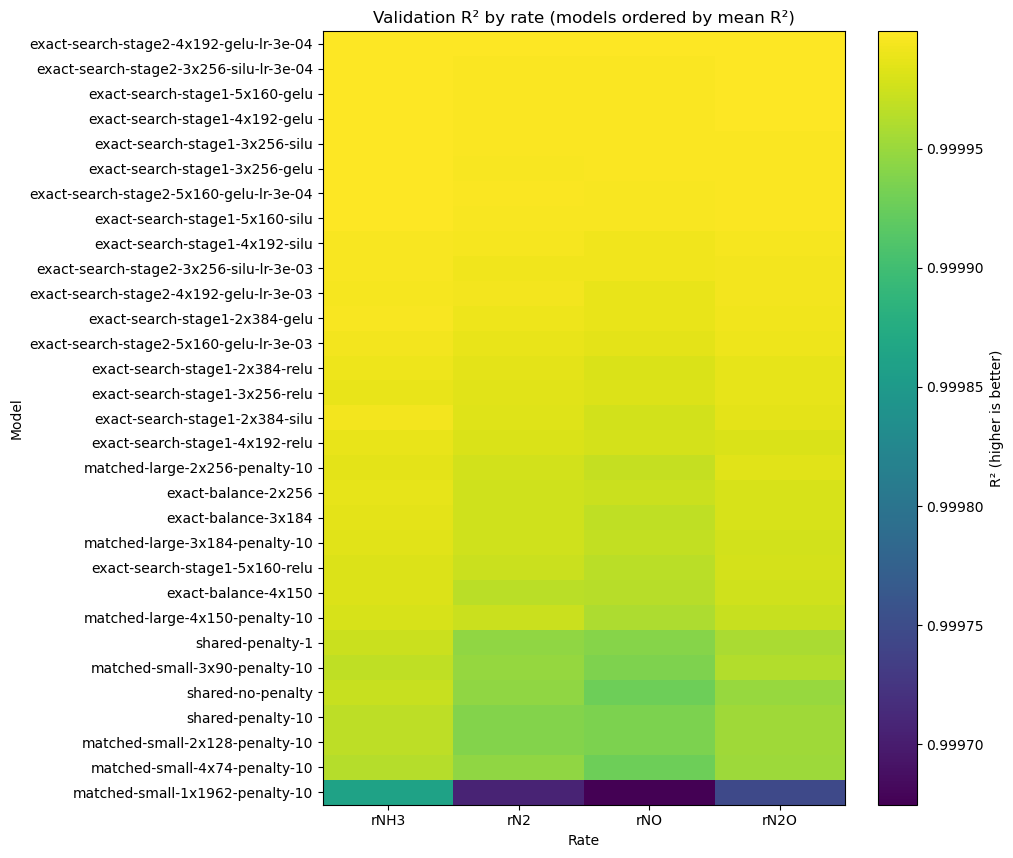

,model,mean_r2,worst_rate_r2,inferences_per_second,milliseconds_per_1000_inferences,device,batch_size
0,exact-search-stage2-4x192-gelu-lr-3e-04,0.999999,0.999999,2.729210e+05,3.664064,cpu,512
1,exact-search-stage2-3x256-silu-lr-3e-04,0.999998,0.999997,2.305200e+05,4.338018,cpu,512
2,exact-search-stage1-5x160-gelu,0.999998,0.999997,2.542996e+05,3.932369,cpu,512
3,exact-search-stage1-4x192-gelu,0.999998,0.999997,2.717150e+05,3.680327,cpu,512
4,exact-search-stage1-3x256-silu,0.999998,0.999997,2.640168e+05,3.787637,cpu,512
5,exact-search-stage1-3x256-gelu,0.999998,0.999997,2.813186e+05,3.554689,cpu,512
6,exact-search-stage2-5x160-gelu-lr-3e-04,0.999997,0.999996,2.442176e+05,4.094709,cpu,512
7,exact-search-stage1-5x160-silu,0.999997,0.999996,2.504802e+05,3.992332,cpu,512
8,exact-search-stage1-4x192-silu,0.999995,0.999992,2.766973e+05,3.614058,cpu,512
9,exact-search-stage2-3x256-silu-lr-3e-03,0.999993,0.999992,2.475440e+05,4.039686,cpu,512


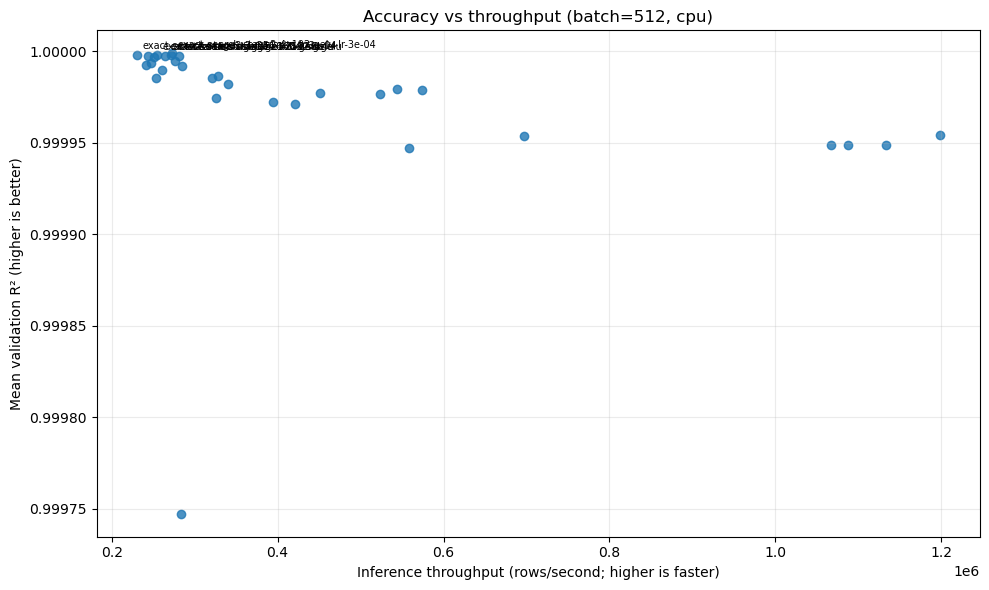

Timing is forward-pass throughput on this device using validation inputs in batches; it excludes preprocessing and may differ for batch size 1, other hardware, or deployment settings.


In [48]:
print('Validation R² and inference-throughput views (no model training).')

if 'mass_balance_error_comparison' not in globals() or mass_balance_error_comparison.empty:
    print('Run the preceding comparison cell first to calculate validation metrics.')
elif 'SHARED_MODELS' not in globals():
    print('No cached shared models are available for inference timing.')
else:
    import time

    rate_r2_columns = [f'{target}_r2' for target in TARGETS]
    r2_plot_data = mass_balance_error_comparison.sort_values(
        ['mean_r2', 'worst_rate_r2'], ascending=[False, False], na_position='last'
    ).reset_index(drop=True)
    r2_values = r2_plot_data[rate_r2_columns].to_numpy(dtype=float)
    finite_r2_values = r2_values[np.isfinite(r2_values)]

    if finite_r2_values.size:
        figure_height = max(6, 0.28 * len(r2_plot_data))
        fig, ax = plt.subplots(figsize=(10, figure_height))
        color_min = float(np.min(finite_r2_values))
        color_max = float(np.max(finite_r2_values))
        if color_min == color_max:
            color_min -= 1e-12
        image = ax.imshow(r2_values, aspect='auto', interpolation='nearest', cmap='viridis', vmin=color_min, vmax=color_max)
        ax.set_yticks(np.arange(len(r2_plot_data)), r2_plot_data['model'])
        ax.set_xticks(np.arange(len(TARGETS)), TARGETS)
        ax.set_title('Validation R² by rate (models ordered by mean R²)')
        ax.set_xlabel('Rate')
        ax.set_ylabel('Model')
        fig.colorbar(image, ax=ax, label='R² (higher is better)')
        fig.tight_layout()
        plt.show()

    TIMING_BATCH_SIZE = 512
    TIMING_REPEATS = 2
    TIMING_WARMUP_BATCHES = 3
    comparison_by_name = mass_balance_error_comparison.set_index('model')
    timing_rows = []

    if 'x_val' not in globals():
        print('Validation inputs x_val are unavailable; inference throughput was not measured.')
    else:
        for model_name in comparison_by_name.index:
            model = SHARED_MODELS.get(model_name)
            if model is None:
                continue

            first_parameter = next(model.parameters(), None)
            if first_parameter is None:
                raise ValueError(f'{model_name}: cannot time a model with no parameters')

            model_device = first_parameter.device
            timing_inputs = torch.as_tensor(x_val, dtype=first_parameter.dtype, device=model_device)
            batches = [timing_inputs[start:start + TIMING_BATCH_SIZE] for start in range(0, len(timing_inputs), TIMING_BATCH_SIZE)]
            if not batches:
                raise ValueError('Cannot benchmark inference because x_val is empty')

            was_training = model.training
            model.eval()
            try:
                with torch.inference_mode():
                    for batch in batches[:TIMING_WARMUP_BATCHES]:
                        model(batch)
                    if model_device.type == 'cuda':
                        torch.cuda.synchronize(model_device)

                    start_time = time.perf_counter()
                    for _ in range(TIMING_REPEATS):
                        for batch in batches:
                            model(batch)
                    if model_device.type == 'cuda':
                        torch.cuda.synchronize(model_device)
                    elapsed_seconds = time.perf_counter() - start_time
            finally:
                model.train(was_training)

            inference_count = len(timing_inputs) * TIMING_REPEATS
            timing_rows.append({
                'model': model_name,
                'mean_r2': float(comparison_by_name.loc[model_name, 'mean_r2']),
                'worst_rate_r2': float(comparison_by_name.loc[model_name, 'worst_rate_r2']),
                'inferences_per_second': inference_count / elapsed_seconds,
                'milliseconds_per_1000_inferences': elapsed_seconds * 1000 / inference_count * 1000,
                'device': str(model_device),
                'batch_size': TIMING_BATCH_SIZE,
            })

    if timing_rows:
        inference_timing_comparison = pd.DataFrame.from_records(timing_rows)
        display(inference_timing_comparison.sort_values(['mean_r2', 'worst_rate_r2'], ascending=[False, False]).reset_index(drop=True))

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(
            inference_timing_comparison['inferences_per_second'],
            inference_timing_comparison['mean_r2'],
            alpha=0.8,
        )
        for _, row in inference_timing_comparison.nlargest(6, 'mean_r2').iterrows():
            ax.annotate(
                row['model'],
                (row['inferences_per_second'], row['mean_r2']),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=7,
            )
        ax.set_xlabel('Inference throughput (rows/second; higher is faster)')
        ax.set_ylabel('Mean validation R² (higher is better)')
        ax.set_title(f'Accuracy vs throughput (batch={TIMING_BATCH_SIZE}, {timing_rows[0]["device"]})')
        ax.grid(True, alpha=0.25)
        fig.tight_layout()
        plt.show()
    else:
        print('No cached model corresponding to the validation comparison table was available for timing.')

    print(
        'Timing is forward-pass throughput on this device using validation inputs in batches; '
        'it excludes preprocessing and may differ for batch size 1, other hardware, or deployment settings.'
    )

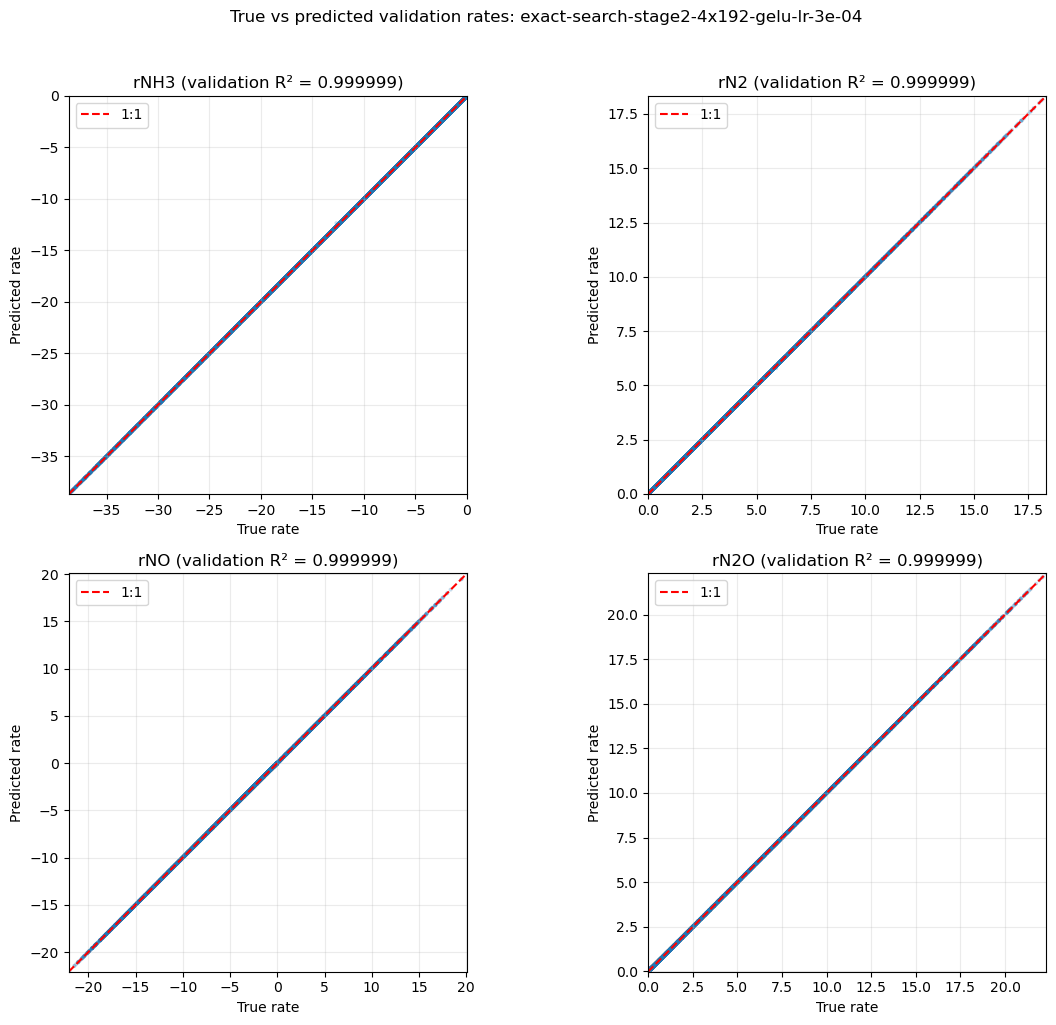

In [49]:
BEST_MODEL_NAME = 'exact-search-stage2-4x192-gelu-lr-3e-04'

if 'SHARED_VALIDATION_PREDICTIONS' not in globals() or BEST_MODEL_NAME not in SHARED_VALIDATION_PREDICTIONS:
    print(f'Cached validation predictions for {BEST_MODEL_NAME!r} are unavailable. Run the model search/results cells first.')
elif 'y_val' not in globals() or 'TARGETS' not in globals():
    print('Validation targets are unavailable. Run the notebook setup cells first.')
else:
    validation_truth = np.asarray(y_val, dtype=np.float64)
    validation_prediction = np.asarray(SHARED_VALIDATION_PREDICTIONS[BEST_MODEL_NAME], dtype=np.float64)
    if validation_prediction.shape != validation_truth.shape:
        raise ValueError(
            f'{BEST_MODEL_NAME}: prediction shape {validation_prediction.shape} does not match '
            f'validation target shape {validation_truth.shape}'
        )

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for target_index, (target, ax) in enumerate(zip(TARGETS, axes.flat)):
        true_rate = validation_truth[:, target_index]
        predicted_rate = validation_prediction[:, target_index]
        lower = float(min(true_rate.min(), predicted_rate.min()))
        upper = float(max(true_rate.max(), predicted_rate.max()))
        ax.scatter(true_rate, predicted_rate, s=8, alpha=0.25, edgecolors='none', rasterized=True)
        ax.plot([lower, upper], [lower, upper], color='red', linestyle='--', linewidth=1.5, label='1:1')
        centered_true = true_rate - true_rate.mean()
        total_sum_squares = np.sum(centered_true ** 2)
        r2 = 1.0 - np.sum((predicted_rate - true_rate) ** 2) / total_sum_squares if total_sum_squares > 0 else np.nan
        ax.set_title(f'{target} (validation R² = {r2:.6f})')
        ax.set_xlabel('True rate')
        ax.set_ylabel('Predicted rate')
        ax.set_xlim(lower, upper)
        ax.set_ylim(lower, upper)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.25)
        ax.legend(loc='best')

    fig.suptitle(f'True vs predicted validation rates: {BEST_MODEL_NAME}', y=1.02)
    fig.tight_layout()
    plt.show()